In [36]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
import pandas as pd
from collections import Counter
pd.set_option('display.precision', 3)
from pandas import read_csv
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import LocalOutlierFactor
from sklearn import preprocessing
from pandas.plotting import scatter_matrix
from scipy.stats import boxcox
from statsmodels.genmod.generalized_linear_model import GLM
from sklearn.model_selection import train_test_split

In [37]:
wifi = pd.read_csv('../data/raw/train_nt.csv', header=0, delimiter=';')
X_test_nolabels = pd.read_csv('../data/raw/test_nolabels_nt.csv', header=0, delimiter=';')
wifi.shape

(12888, 262)

In [38]:
wifi.head()

,ID,seq_ctrl,aoa,rssi1,rssi2,I0_1,Q0_1,I1_1,Q1_1,I2_1,...,Q59_2,I60_2,Q60_2,I61_2,Q61_2,I62_2,Q62_2,I63_2,Q63_2,position
0,0,0,-5703,-88,-88,0,0,4,5,7,...,-13,6,-13,-2,-8,3,-12,1,-12,9
1,1,0,1835,-91,-88,0,0,-10,4,-7,...,-7,-11,-9,-18,-7,-8,-8,-8,-10,9
2,2,0,4,-86,-87,0,0,5,14,5,...,10,7,16,7,13,11,16,11,13,9
3,3,52464,1259,-81,-71,0,0,-1,12,1,...,13,-7,14,-6,17,-6,16,-7,16,2
4,4,0,900,-82,-76,0,0,9,2,9,...,6,14,4,16,7,14,7,14,2,2


In [39]:
wifi.describe()

,ID,seq_ctrl,aoa,rssi1,rssi2,I0_1,Q0_1,I1_1,Q1_1,I2_1,...,Q59_2,I60_2,Q60_2,I61_2,Q61_2,I62_2,Q62_2,I63_2,Q63_2,position
count,12888.000,12888.000,12888.000,12888.000,12888.000,12888.0,12888.0,12888.000,12888.000,12888.000,...,12888.000,12888.000,12888.000,12888.000,12888.000,12888.000,12888.000,12888.000,12888.000,12888.000
mean,6443.500,16008.410,15.017,-78.052,-77.952,0.0,0.0,-0.406,-0.478,-0.500,...,-0.402,-0.355,-0.296,-0.328,-0.295,-0.311,-0.269,-0.241,-0.363,4.493
std,3720.589,19829.509,3087.311,6.805,8.349,0.0,0.0,10.209,10.123,10.416,...,10.549,10.407,10.520,11.013,11.160,11.075,11.248,11.018,11.118,2.871
min,0.000,0.000,-8703.000,-97.000,-94.000,0.0,0.0,-25.000,-26.000,-24.000,...,-25.000,-25.000,-26.000,-32.000,-38.000,-25.000,-26.000,-27.000,-31.000,0.000
25%,3221.750,0.000,-1751.000,-83.000,-84.000,0.0,0.0,-10.000,-10.000,-10.000,...,-10.000,-10.000,-10.000,-10.000,-10.000,-11.000,-11.000,-10.000,-11.000,2.000
50%,6443.500,5464.000,-30.000,-80.000,-80.000,0.0,0.0,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,5.000
75%,9665.250,29424.000,1798.000,-74.000,-71.000,0.0,0.0,9.000,9.000,9.000,...,9.000,9.000,9.000,10.000,10.000,10.000,10.000,10.000,10.000,7.000
max,12887.000,65520.000,8915.000,-58.000,-58.000,0.0,0.0,25.000,25.000,23.000,...,23.000,29.000,23.000,33.000,35.000,25.000,25.000,26.000,26.000,9.000


In [40]:
wifi.dtypes

ID          int64
seq_ctrl    int64
aoa         int64
rssi1       int64
rssi2       int64
            ...  
I62_2       int64
Q62_2       int64
I63_2       int64
Q63_2       int64
position    int64
Length: 262, dtype: object

In [41]:
print(wifi.isnull().values.any()) # no hay supuestos NA
print((wifi == " ").sum().sum())
print((wifi == "").sum().sum())

False
0
0


Si nos fijamos en la descripción del dataset, seq_ctrl: uint16 sequence numbers. Por lo tanto, seq_ctrl [0,2^16 -1] = [0, 65535].
Los últimos números se guardan para detectar errores?


In [42]:
print((wifi["seq_ctrl"] >= 65520).sum().sum()) #posibles errores

3


In [43]:
print(wifi["position"].value_counts())

position
1    1488
5    1397
8    1312
7    1278
9    1273
4    1249
3    1237
6    1230
2    1224
0    1200
Name: count, dtype: int64


array([<Axes: title={'center': 'seq_ctrl'}>], dtype=object)

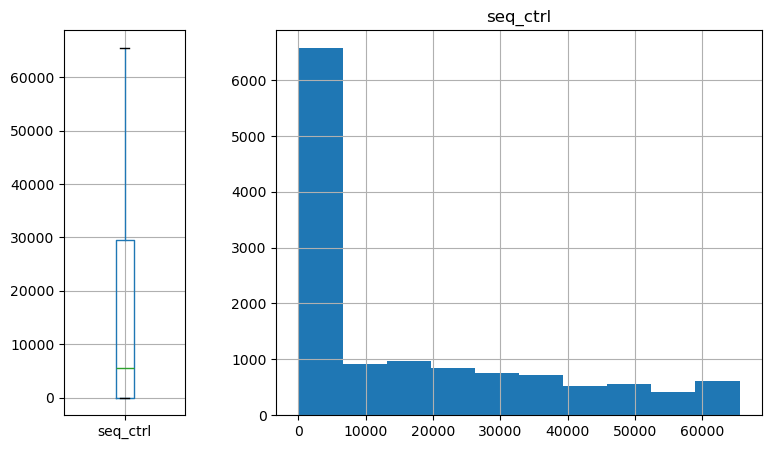

In [44]:
fig, axes= plt.subplots(1,2, gridspec_kw={'width_ratios': [1, 4]}, figsize=(9,5))
wifi.boxplot(column='seq_ctrl',ax=axes[0])
wifi.hist(column='seq_ctrl', ax=axes[1])

array([<Axes: title={'center': 'aoa'}>], dtype=object)

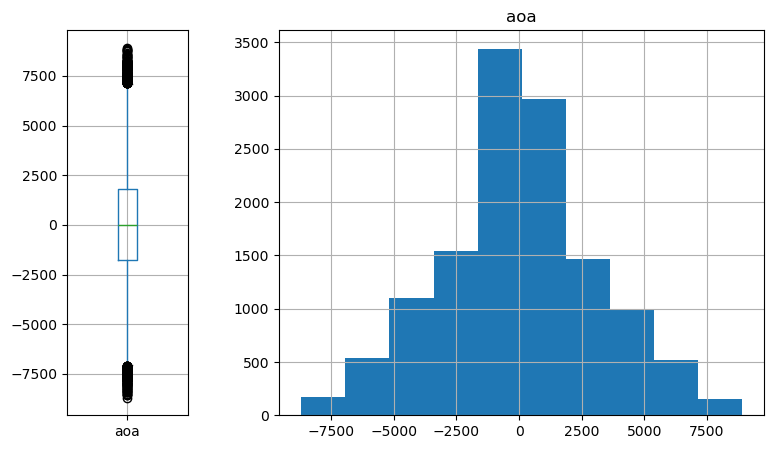

In [45]:
fig, axes= plt.subplots(1,2, gridspec_kw={'width_ratios': [1, 4]}, figsize=(9,5))
wifi.boxplot(column='aoa',ax=axes[0])
wifi.hist(column='aoa', ax=axes[1])

array([<Axes: title={'center': 'rssi1'}>], dtype=object)

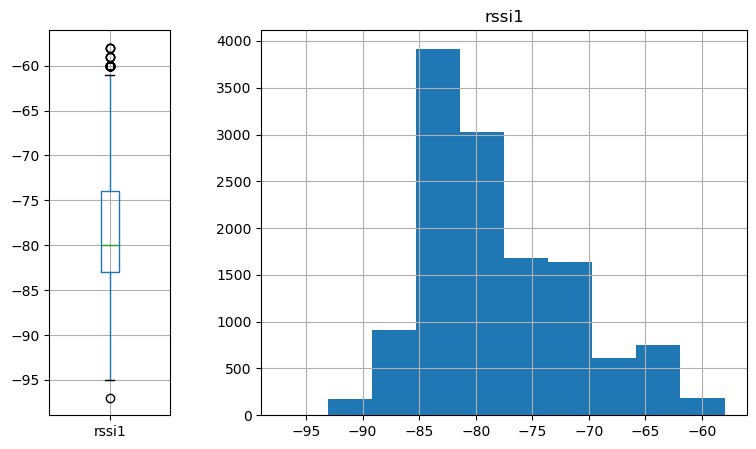

In [46]:
fig, axes= plt.subplots(1,2, gridspec_kw={'width_ratios': [1, 4]}, figsize=(9,5))
wifi.boxplot(column='rssi1',ax=axes[0])
wifi.hist(column='rssi1', ax=axes[1])

array([<Axes: title={'center': 'rssi2'}>], dtype=object)

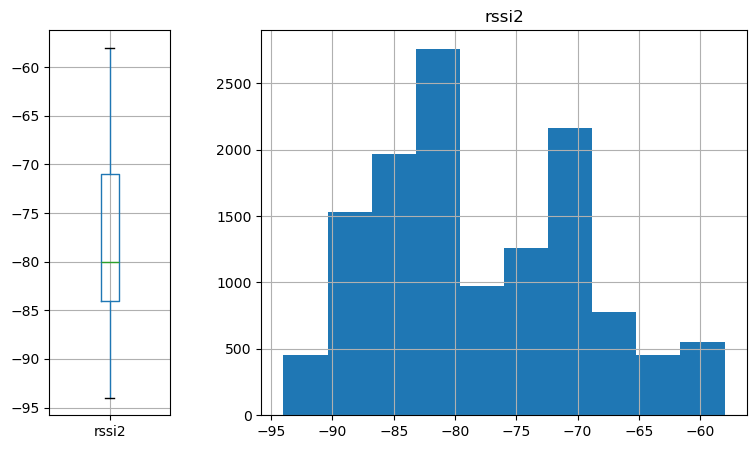

In [47]:
fig, axes= plt.subplots(1,2, gridspec_kw={'width_ratios': [1, 4]}, figsize=(9,5))
wifi.boxplot(column='rssi2',ax=axes[0])
wifi.hist(column='rssi2', ax=axes[1])

In [48]:
y, X = wifi['position'], wifi.drop('position', axis=1)

# NUEVAS VARIABLES

In [49]:
def create_features(X: pd.DataFrame) -> pd.DataFrame:

    features = ['seq_ctrl', 'aoa', 'rssi1', 'rssi2']
    
    # Subportadoras útiles (excluye DC y guardas nulas de 802.11)
    valid_subs = [n for n in range(64) if n not in {0, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37}]

    new_cols = {}
    magnitude = []
    phase_cols = []

    for antena in [1, 2]:
        for n in valid_subs:
            i_col = f"I{n}_{antena}"
            q_col = f"Q{n}_{antena}"

            mag_col   = f"mag{n}_{antena}"
            phase_col = f"phase{n}_{antena}"

            new_cols[mag_col]   = np.sqrt(X[i_col]**2 + X[q_col]**2)
            new_cols[phase_col] = np.arctan2(X[q_col], X[i_col])
            magnitude.append(mag_col)
            phase_cols.append(phase_col)

    X = pd.concat([X, pd.DataFrame(new_cols, index=X.index)], axis=1)
    X = X[features + magnitude + phase_cols]

    # Columnas constantes (detectar aquí solo si es train; en test aplicar la misma lista)
    const_col = [col for col in X.columns if X[col].nunique() <= 1]
    print(f"Columnas eliminadas: {const_col}")
    X = X.drop(columns=const_col)

    # Phase differences (solo subportadoras que sobrevivieron)
    phase_diff_cols = {}
    for n in valid_subs:
        col1, col2 = f"phase{n}_1", f"phase{n}_2"
        if col1 in X.columns and col2 in X.columns:
            phase_diff_cols[f"phase_diff{n}"] = X[col1] - X[col2]

    X = pd.concat([X, pd.DataFrame(phase_diff_cols, index=X.index)], axis=1)

    # Stats
    stats_cols = {}
    for antena in [1, 2]:
        mag_cols_ant   = [f"mag{n}_{antena}"   for n in valid_subs if f"mag{n}_{antena}"   in X.columns]
        phase_cols_ant = [f"phase{n}_{antena}" for n in valid_subs if f"phase{n}_{antena}" in X.columns]

        mags   = X[mag_cols_ant].values
        phases = X[phase_cols_ant].values

        stats_cols[f"mean_mag_{antena}"] = mags.mean(axis=1)
        stats_cols[f"std_mag_{antena}"]  = mags.std(axis=1)
        stats_cols[f"max_mag_{antena}"]  = mags.max(axis=1)

        stats_cols[f"mean_cos_{antena}"] = (mags * np.cos(phases)).mean(axis=1)
        stats_cols[f"mean_sin_{antena}"] = (mags * np.sin(phases)).mean(axis=1)

        weights        = mags / (mags.sum(axis=1, keepdims=True) + 1e-9)
        w_phase_mean   = (weights * phases).sum(axis=1)           # calcular primero
        stats_cols[f"weighted_phase_mean_{antena}"] = w_phase_mean
        stats_cols[f"weighted_phase_std_{antena}"]  = np.sqrt(    # usar la variable, no el dict
            (weights * (phases - w_phase_mean[:, None])**2).sum(axis=1)
        )

        stats_cols[f"circular_mean_r_{antena}"] = np.sqrt(
        stats_cols[f"mean_cos_{antena}"]**2 +
        stats_cols[f"mean_sin_{antena}"]**2) / (stats_cols[f"mean_mag_{antena}"] + 1e-9)

    X = pd.concat([X, pd.DataFrame(stats_cols, index=X.index)], axis=1)

    return X.copy()

X_new = create_features(X)
X_test_nolabels = create_features(X_test_nolabels)

X_train, X_test, y_train, y_test = train_test_split(X_new, y, test_size=0.2, random_state=42)


Columnas eliminadas: []
Columnas eliminadas: []


In [50]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(10310, 280) (10310,)
(2578, 280) (2578,)


# OUTLIER DETECTION  (seq_ctrl, aoa, rssi1, rssi2) 

## seq_ctrl
Variable que no modificaremos (no sirve?)

array([<Axes: title={'center': 'seq_ctrl'}>], dtype=object)

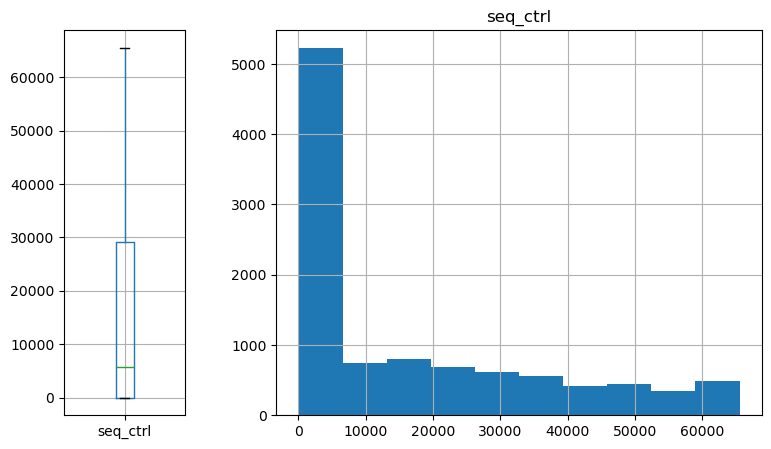

In [51]:
fig, axes= plt.subplots(1,2, gridspec_kw={'width_ratios': [1, 4]}, figsize=(9,5))
X_train.boxplot(column='seq_ctrl',ax=axes[0])
X_train.hist(column='seq_ctrl', ax=axes[1])

## aoa

array([<Axes: title={'center': 'aoa'}>], dtype=object)

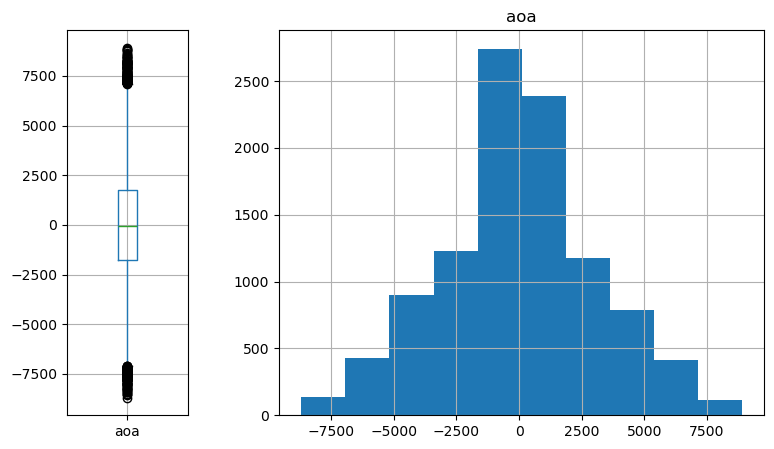

In [52]:
fig, axes= plt.subplots(1,2, gridspec_kw={'width_ratios': [1, 4]}, figsize=(9,5))
X_train.boxplot(column='aoa',ax=axes[0])
X_train.hist(column='aoa', ax=axes[1])

In [53]:
local_outlier_factor = LocalOutlierFactor(n_neighbors=20)
result = local_outlier_factor.fit_predict(X_train['aoa'].values.reshape(-1, 1))

outliers = result == -1
no_outliers = result == 1

Counter(result)

C:\Users\dijor\AppData\Roaming\Python\Python313\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


Counter({np.int64(1): 10254, np.int64(-1): 56})

array([<Axes: title={'center': 'aoa'}>], dtype=object)

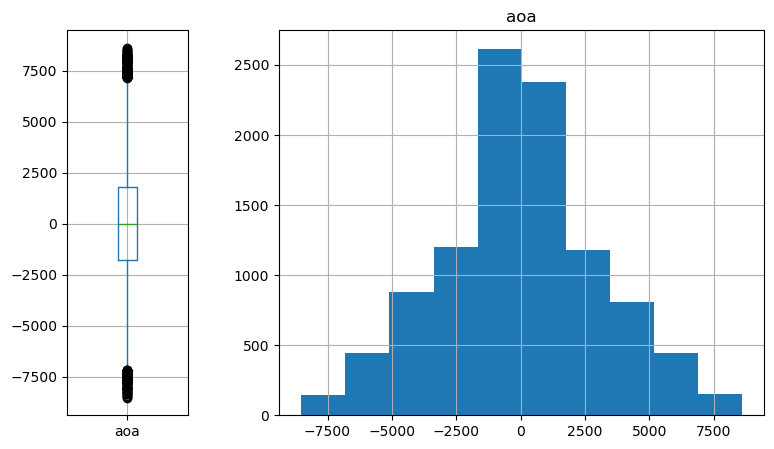

In [54]:
fig, axes= plt.subplots(1,2, gridspec_kw={'width_ratios': [1, 4]}, figsize=(9,5))
X_train[no_outliers].boxplot(column='aoa',ax=axes[0])
X_train[no_outliers].hist(column='aoa', ax=axes[1])

In [55]:
X_train_filtered = X_train[no_outliers]
y_train_filtered = y_train[no_outliers]

In [56]:
X_train_filtered.shape, y_train_filtered.shape

((10254, 280), (10254,))

## rssi1

array([<Axes: title={'center': 'rssi1'}>], dtype=object)

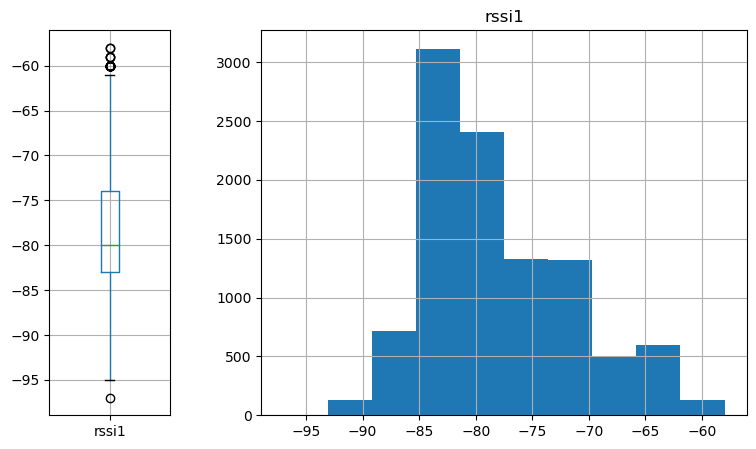

In [57]:
fig, axes= plt.subplots(1,2, gridspec_kw={'width_ratios': [1, 4]}, figsize=(9,5))
X_train_filtered.boxplot(column='rssi1',ax=axes[0])
X_train_filtered.hist(column='rssi1', ax=axes[1])

In [58]:
local_outlier_factor = LocalOutlierFactor(n_neighbors=20)
result = local_outlier_factor.fit_predict(X_train_filtered['rssi1'].values.reshape(-1, 1))

outliers = result == -1
no_outliers = result == 1

Counter(result)

C:\Users\dijor\AppData\Roaming\Python\Python313\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


Counter({np.int64(1): 10228, np.int64(-1): 26})

array([<Axes: title={'center': 'rssi1'}>], dtype=object)

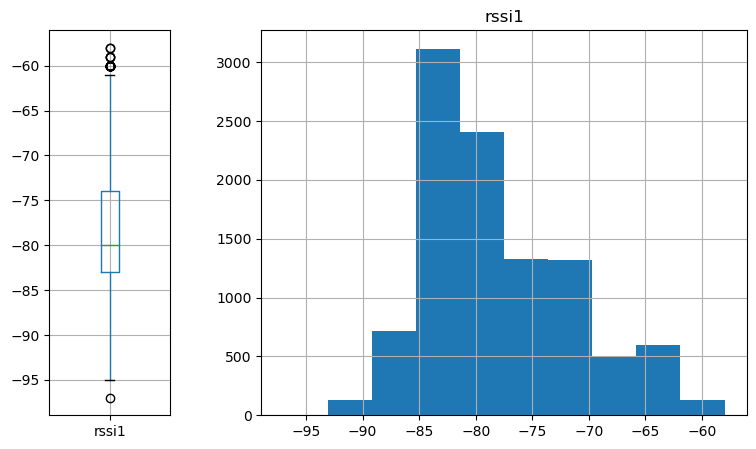

In [59]:
fig, axes= plt.subplots(1,2, gridspec_kw={'width_ratios': [1, 4]}, figsize=(9,5))
X_train_filtered.boxplot(column='rssi1',ax=axes[0])
X_train_filtered.hist(column='rssi1', ax=axes[1])

In [60]:
X_train_filtered = X_train_filtered[no_outliers]
y_train_filtered = y_train_filtered[no_outliers]

In [61]:
X_train_filtered.shape, y_train_filtered.shape

((10228, 280), (10228,))

## rssi2

array([<Axes: title={'center': 'rssi2'}>], dtype=object)

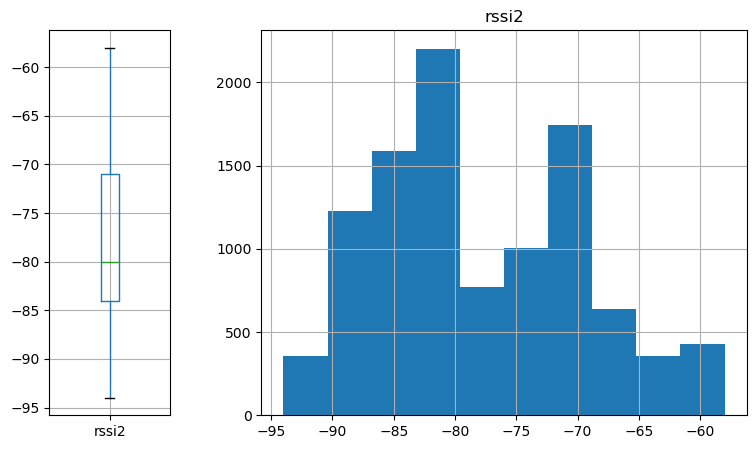

In [62]:
fig, axes= plt.subplots(1,2, gridspec_kw={'width_ratios': [1, 4]}, figsize=(9,5))
X_train_filtered.boxplot(column='rssi2',ax=axes[0])
X_train.hist(column='rssi2', ax=axes[1])

In [63]:
local_outlier_factor = LocalOutlierFactor(n_neighbors=20)
result = local_outlier_factor.fit_predict(X_train_filtered['rssi2'].values.reshape(-1, 1))

outliers = result == -1
no_outliers = result == 1

Counter(result)

C:\Users\dijor\AppData\Roaming\Python\Python313\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


Counter({np.int64(1): 10210, np.int64(-1): 18})

array([<Axes: title={'center': 'rssi2'}>], dtype=object)

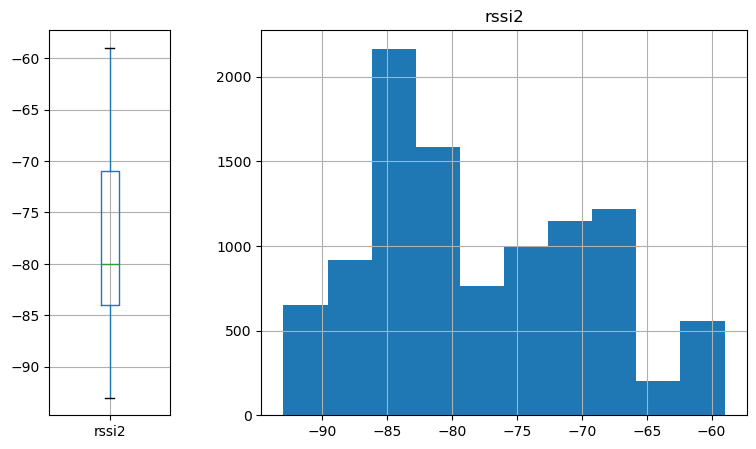

In [64]:
fig, axes= plt.subplots(1,2, gridspec_kw={'width_ratios': [1, 4]}, figsize=(9,5))
X_train_filtered[no_outliers].boxplot(column='rssi2',ax=axes[0])
X_train_filtered[no_outliers].hist(column='rssi2', ax=axes[1])

In [65]:
X_train_filtered = X_train_filtered[no_outliers]
y_train_filtered = y_train_filtered[no_outliers]


print(X_train_filtered.shape, y_train_filtered.shape)


(10210, 280) (10210,)


In [66]:
print(X_train_filtered.shape, y_train_filtered.shape)

(10210, 280) (10210,)


In [67]:
def plot_feature_histograms(df: pd.DataFrame, n_cols_grid: int = 5, bins: int = 40,
                             by_class: bool = False, class_col: str = "position",
                             output_dir: str = None):
    """
    Visualiza histogramas de todas las features en cuadrículas 5x5.

    Parámetros
    ----------
    df         : DataFrame con las features (y opcionalmente la columna de clase)
    n_cols_grid: columnas por fila (default 5 → cuadrícula 5x5)
    bins       : bins del histograma
    by_class   : si True, colorea cada clase por separado
    class_col  : nombre de la columna de clase (default "position")
    output_dir : si se indica, guarda los PNGs en esa carpeta en vez de mostrarlos
    """
    import math
    from pathlib import Path

    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    feature_cols = [c for c in df.columns if c != class_col]
    n_per_page   = n_cols_grid ** 2
    output_path  = Path(output_dir) if output_dir else None
    if output_path:
        output_path.mkdir(parents=True, exist_ok=True)

    for page_start in range(0, len(feature_cols), n_per_page):
        block  = feature_cols[page_start : page_start + n_per_page]
        n_rows = math.ceil(len(block) / n_cols_grid)
        page_n = page_start // n_per_page + 1

        fig, axes = plt.subplots(n_rows, n_cols_grid,
                                 figsize=(n_cols_grid * 3, n_rows * 2.4))
        axes = np.array(axes).flatten()
        fig.suptitle(f"Features — pág {page_n}", fontsize=13, fontweight="bold", y=1.01)

        for j, col in enumerate(block):
            ax = axes[j]
            if by_class and class_col in df.columns:
                for k, cls in enumerate(sorted(df[class_col].unique())):
                    ax.hist(df.loc[df[class_col] == cls, col].dropna(),
                            bins=bins, alpha=0.5,
                            color=colors[k % len(colors)], label=f"cls {cls}")
            else:
                ax.hist(df[col].dropna(), bins=bins,
                        color="steelblue", edgecolor="none", alpha=0.85)

            ax.set_title(col, fontsize=8, pad=3)
            ax.tick_params(labelsize=7)

        for k in range(len(block), len(axes)):
            axes[k].axis("off")

        plt.tight_layout()

        if output_path:
            fpath = output_path / f"features_p{page_n}.png"
            plt.savefig(fpath, dpi=120, bbox_inches="tight")
            plt.close()
        else:
            plt.show()
            plt.close()

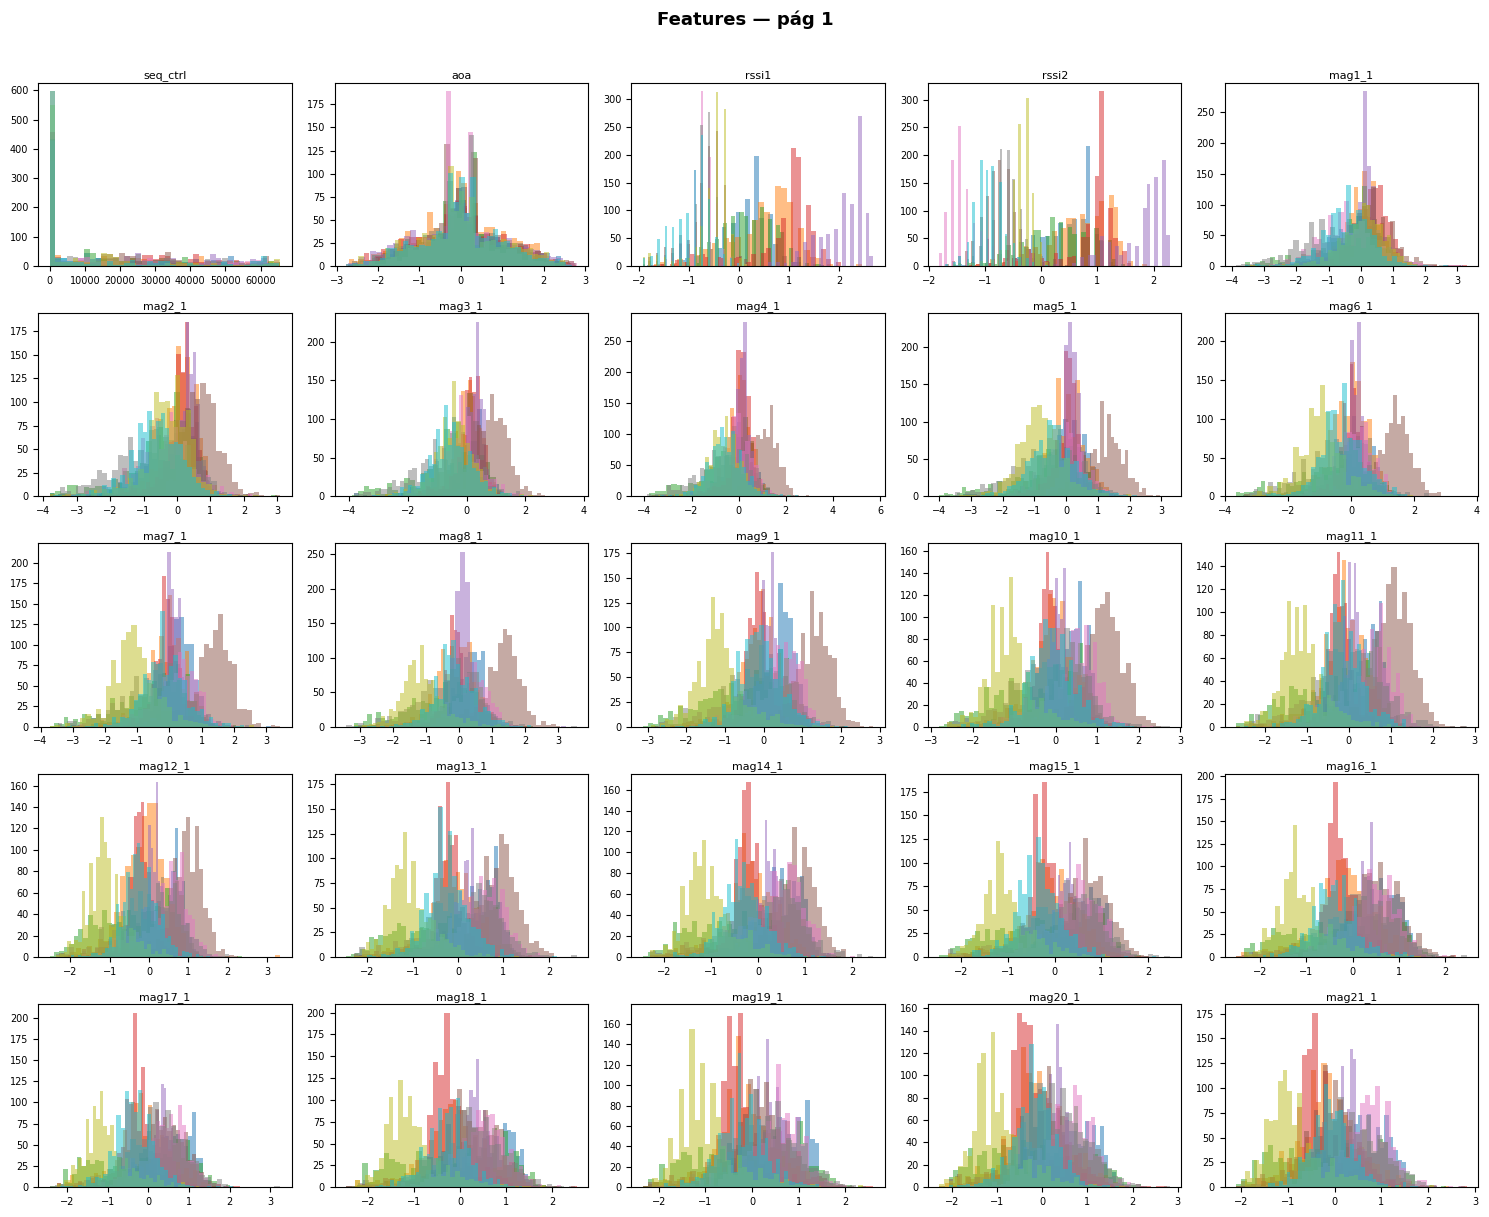

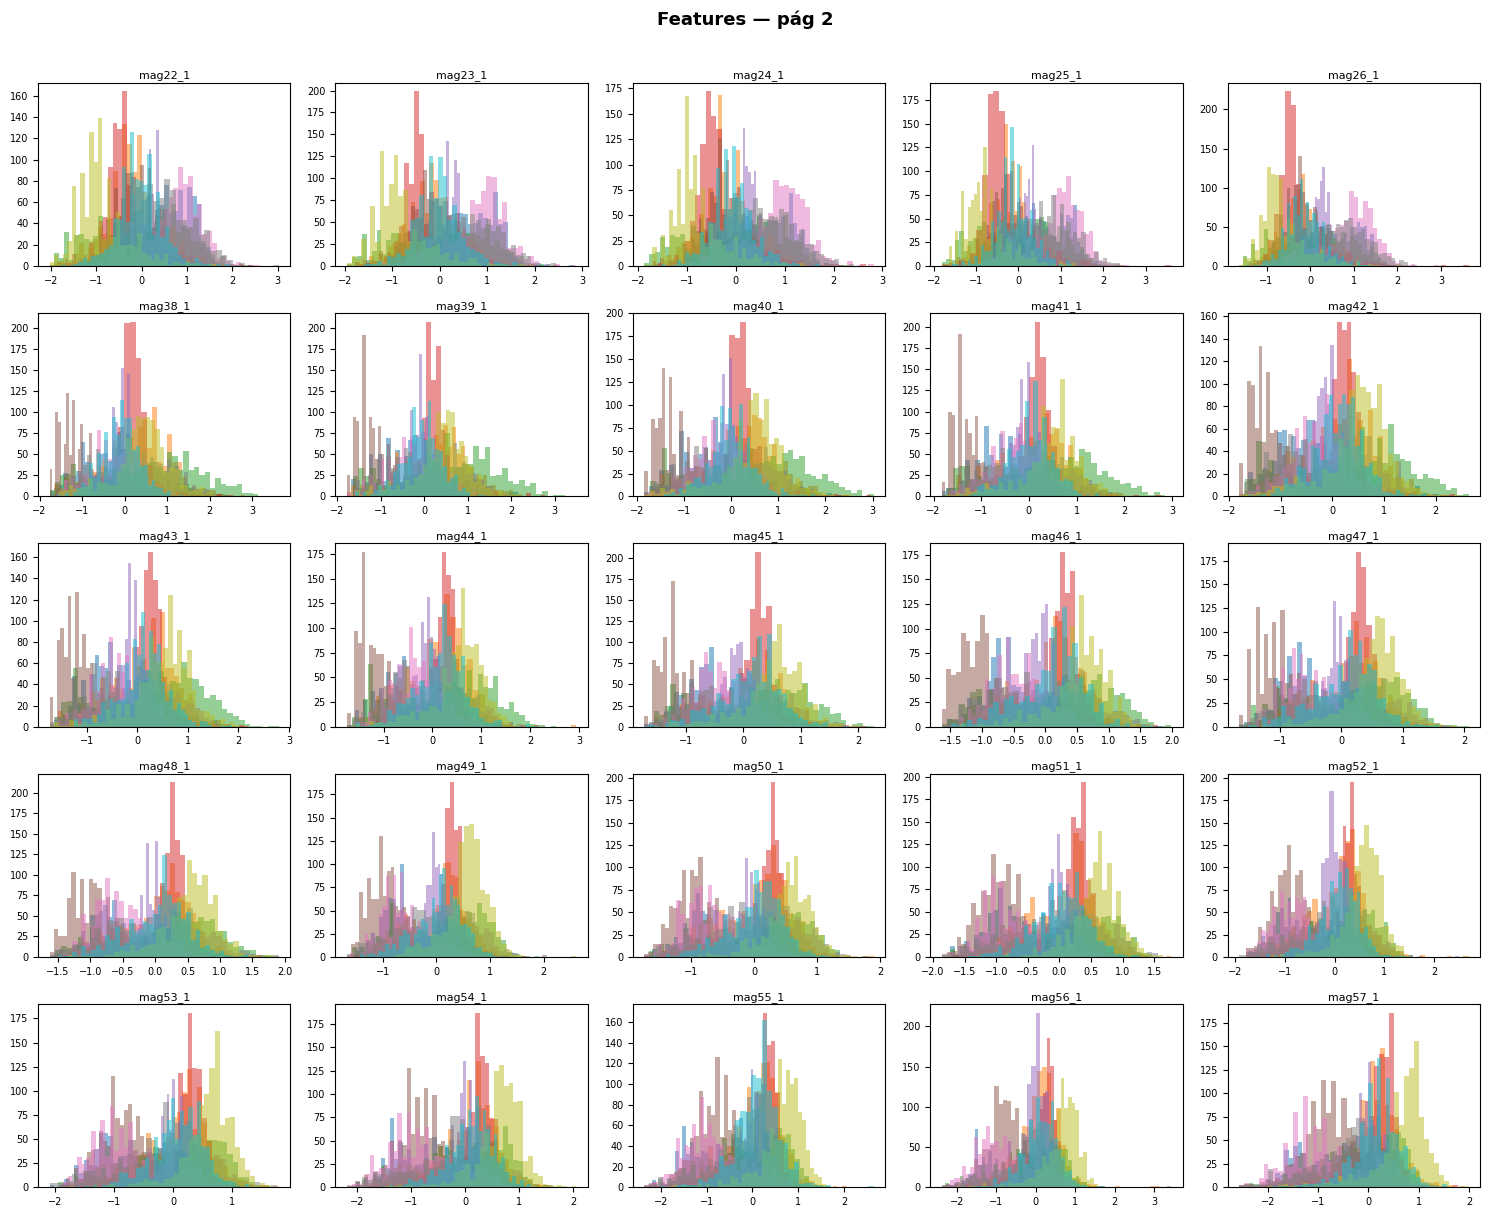

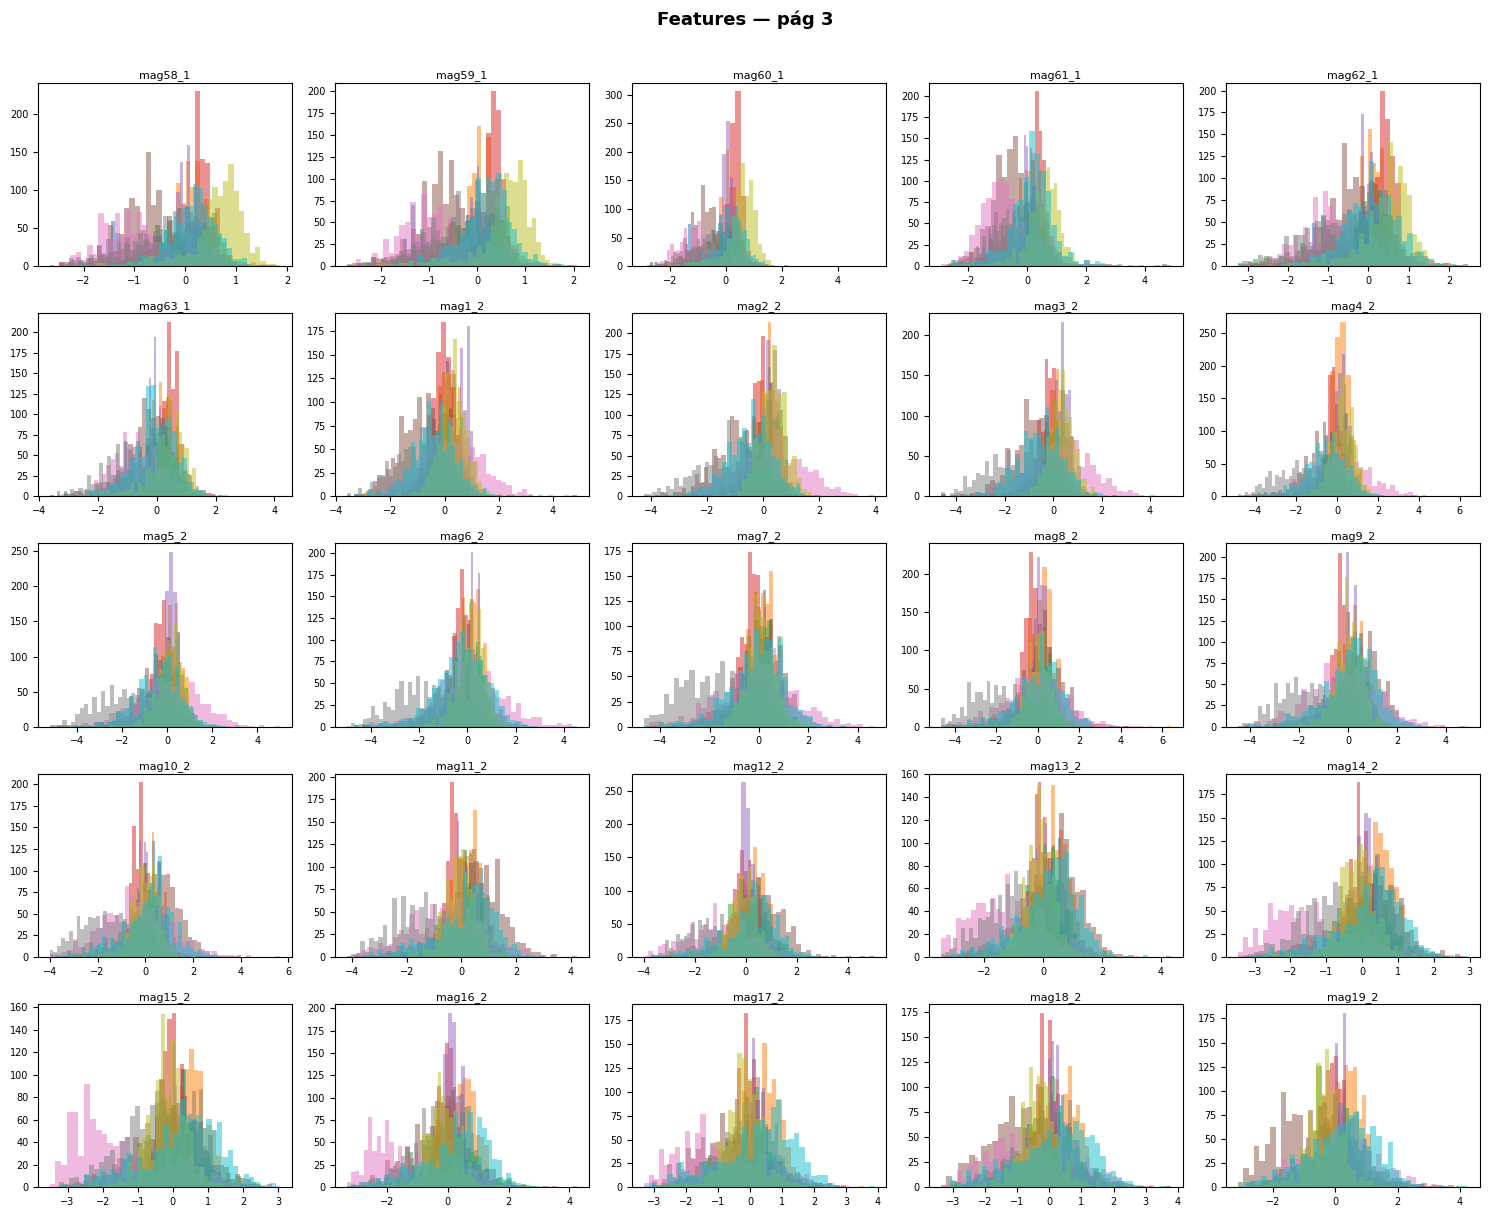

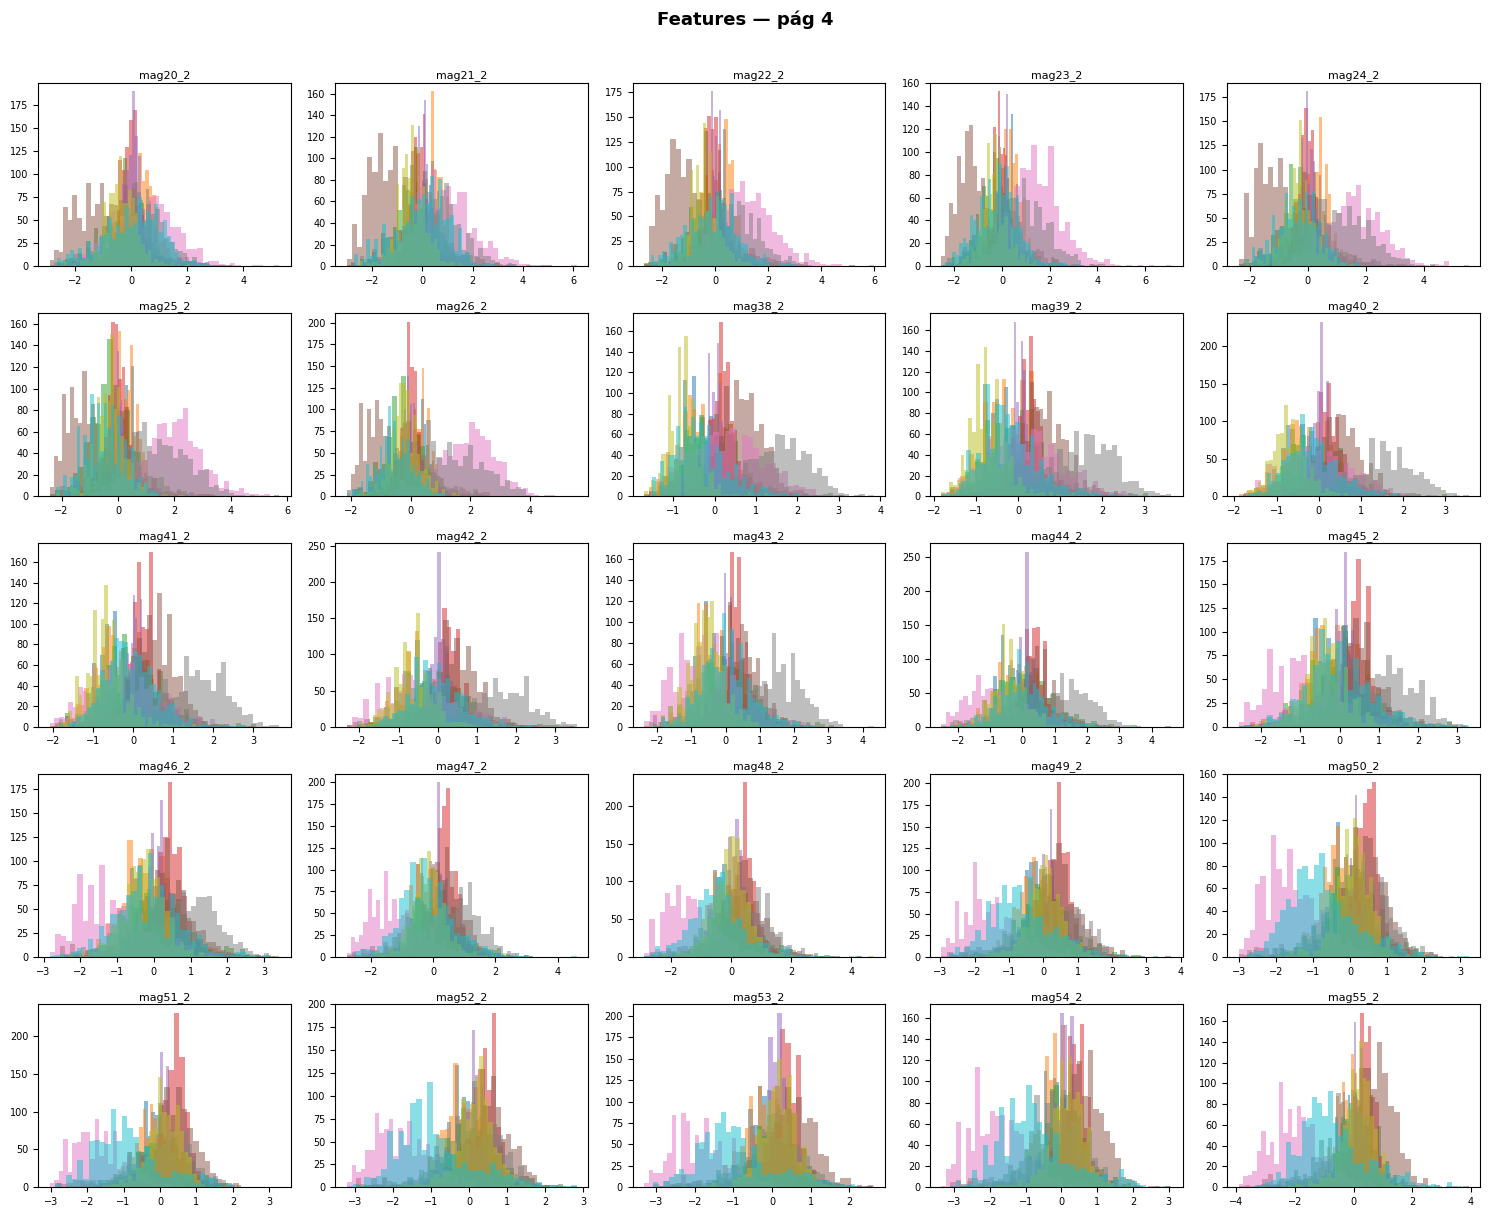

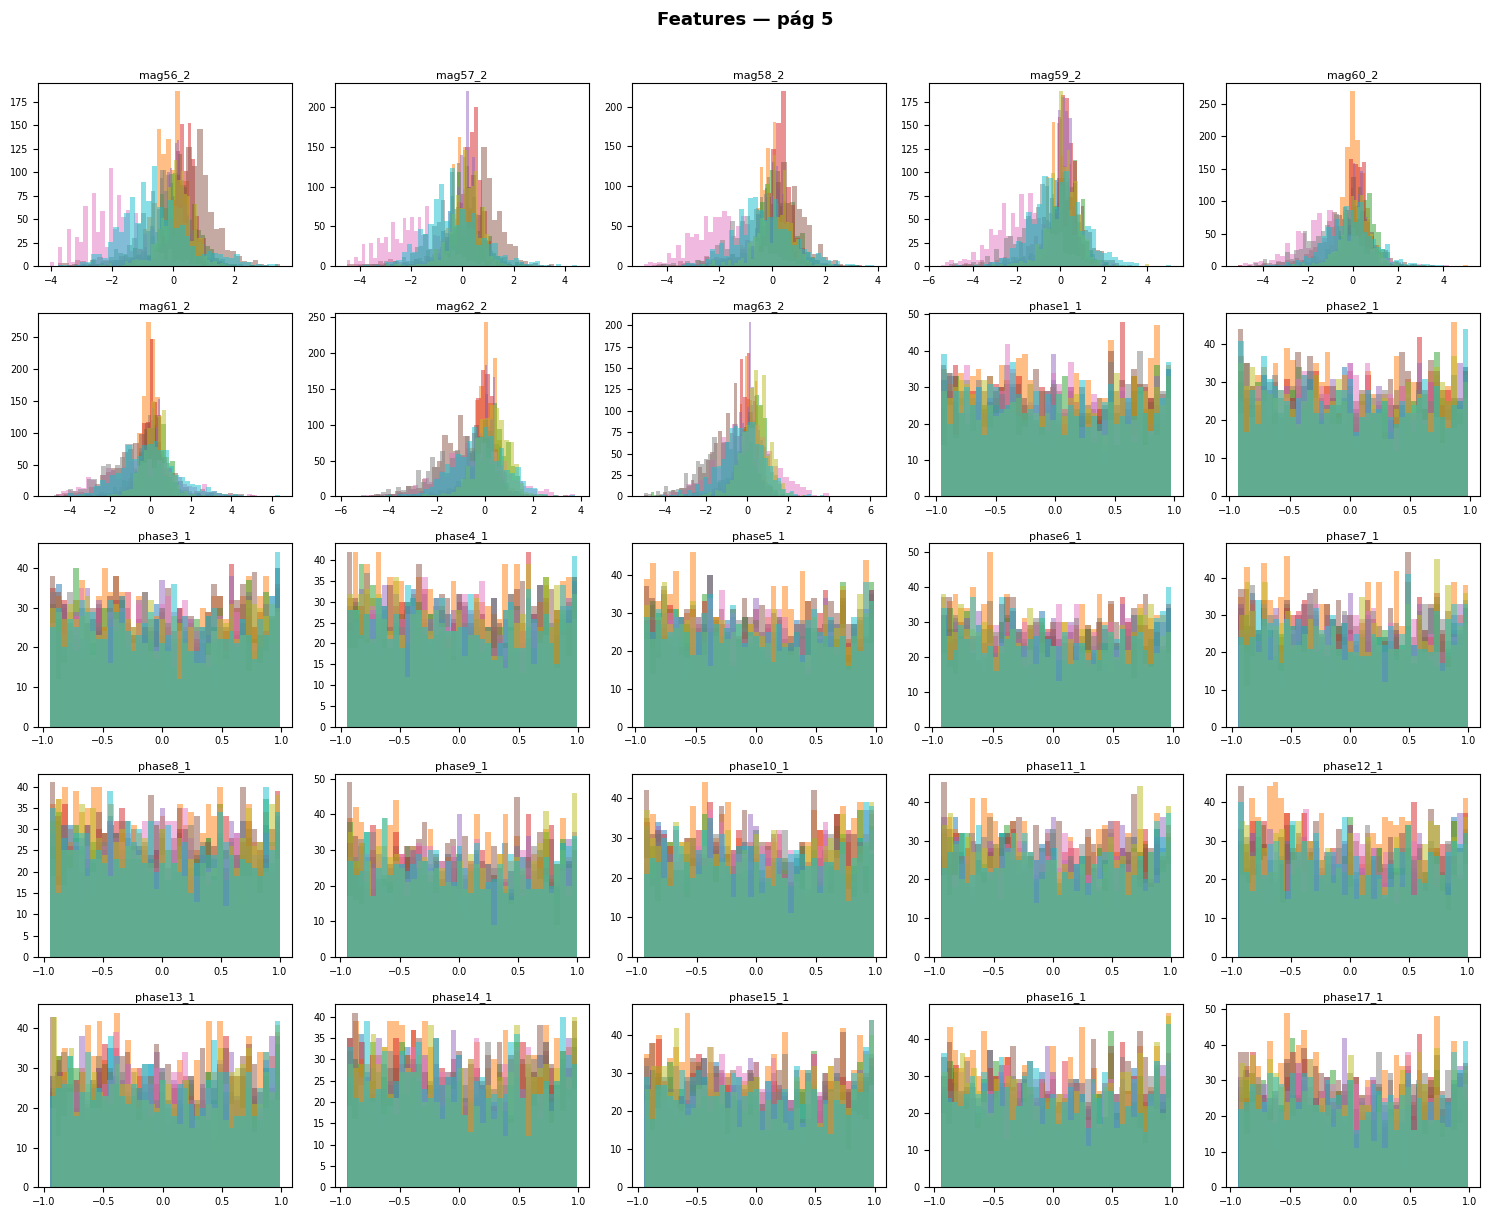

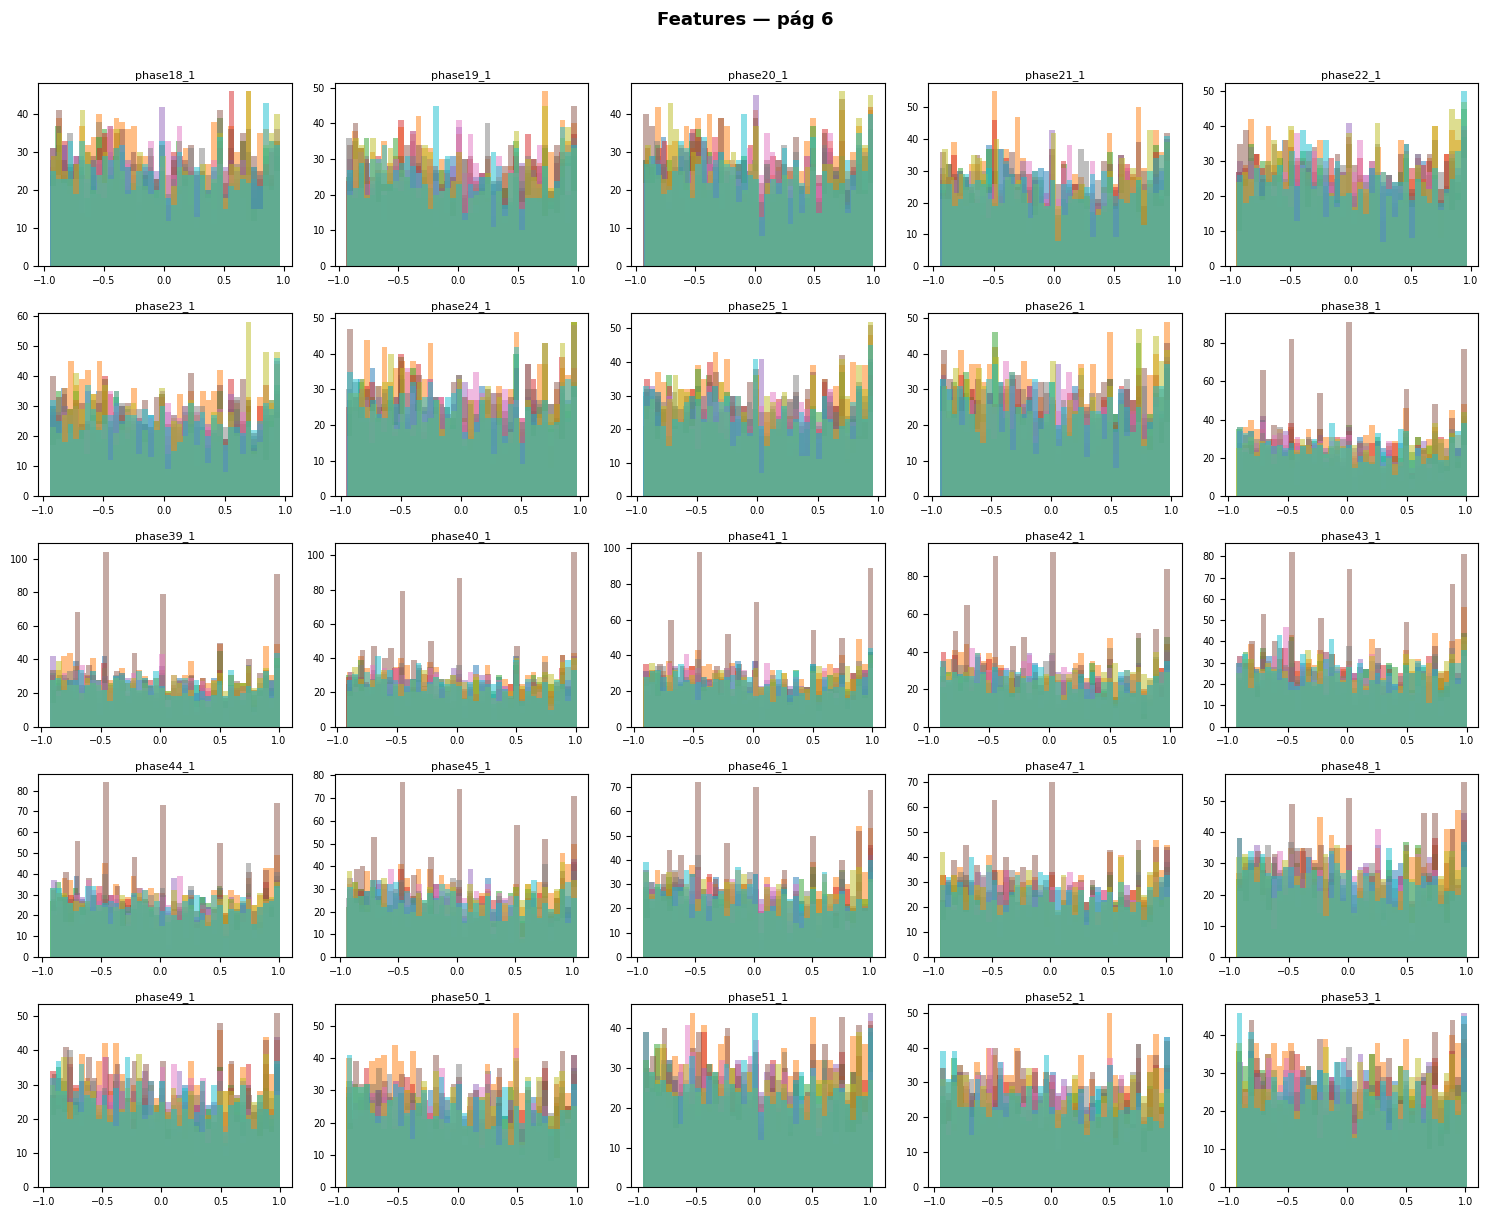

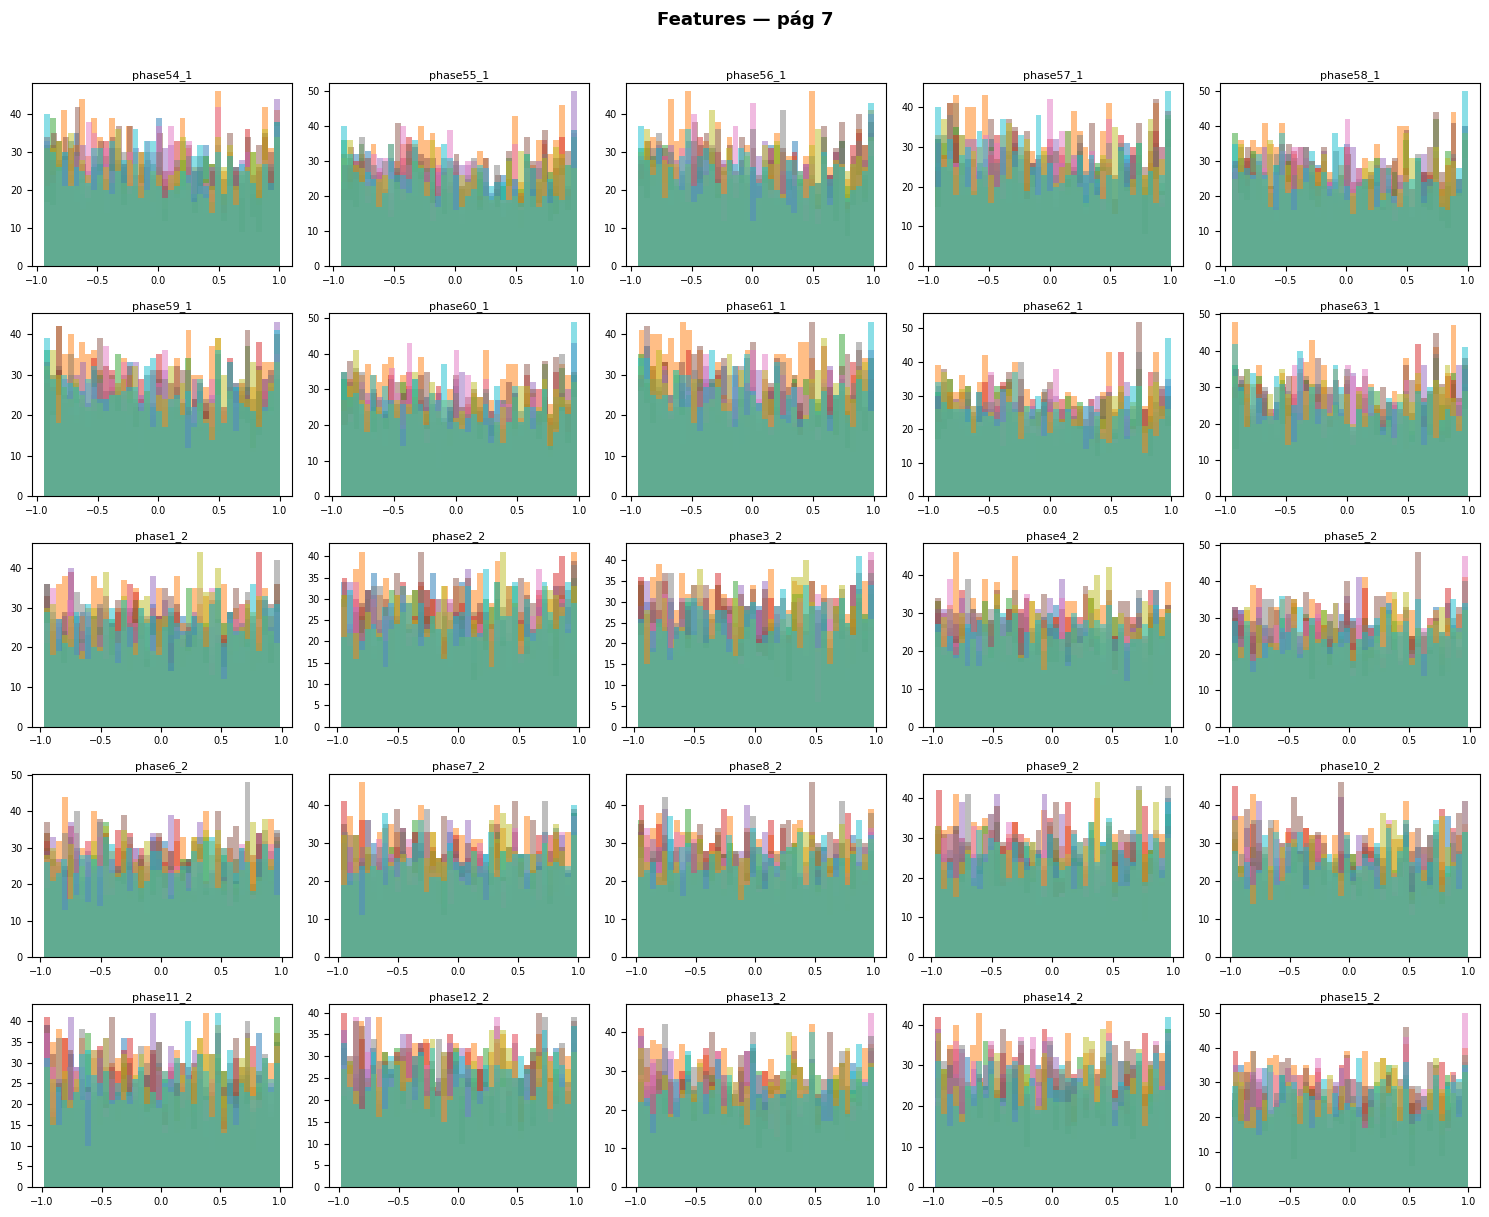

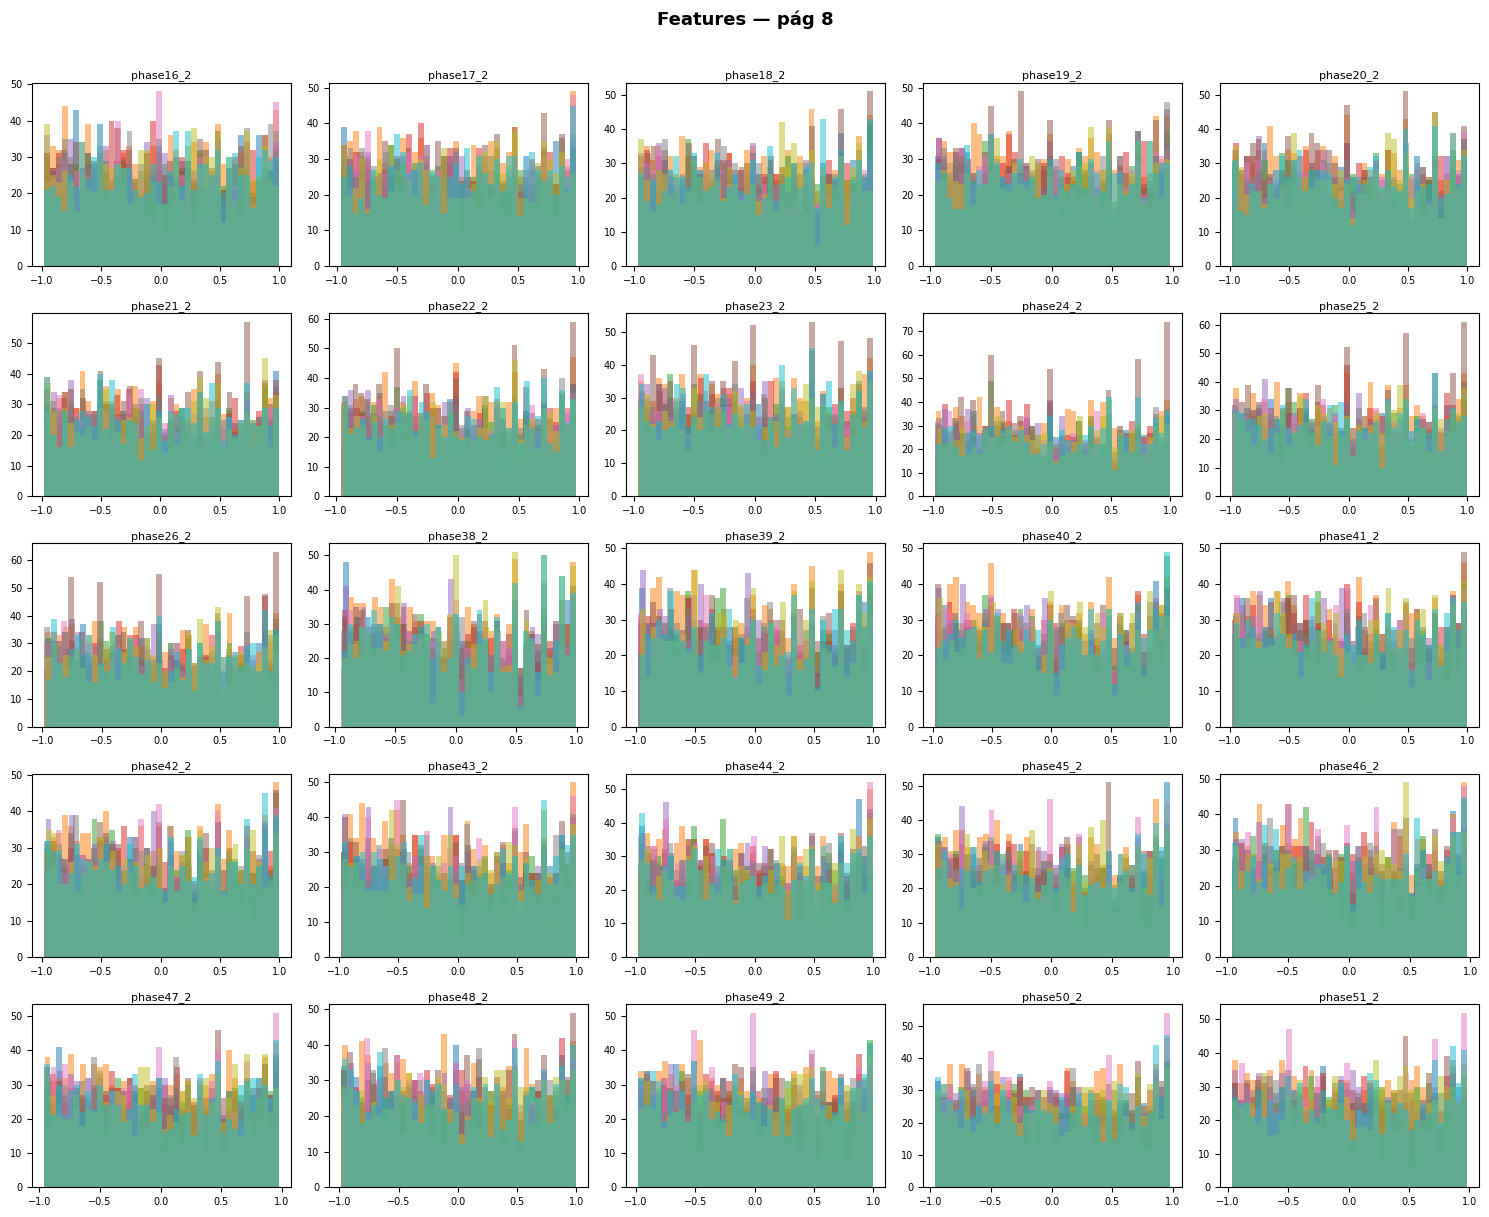

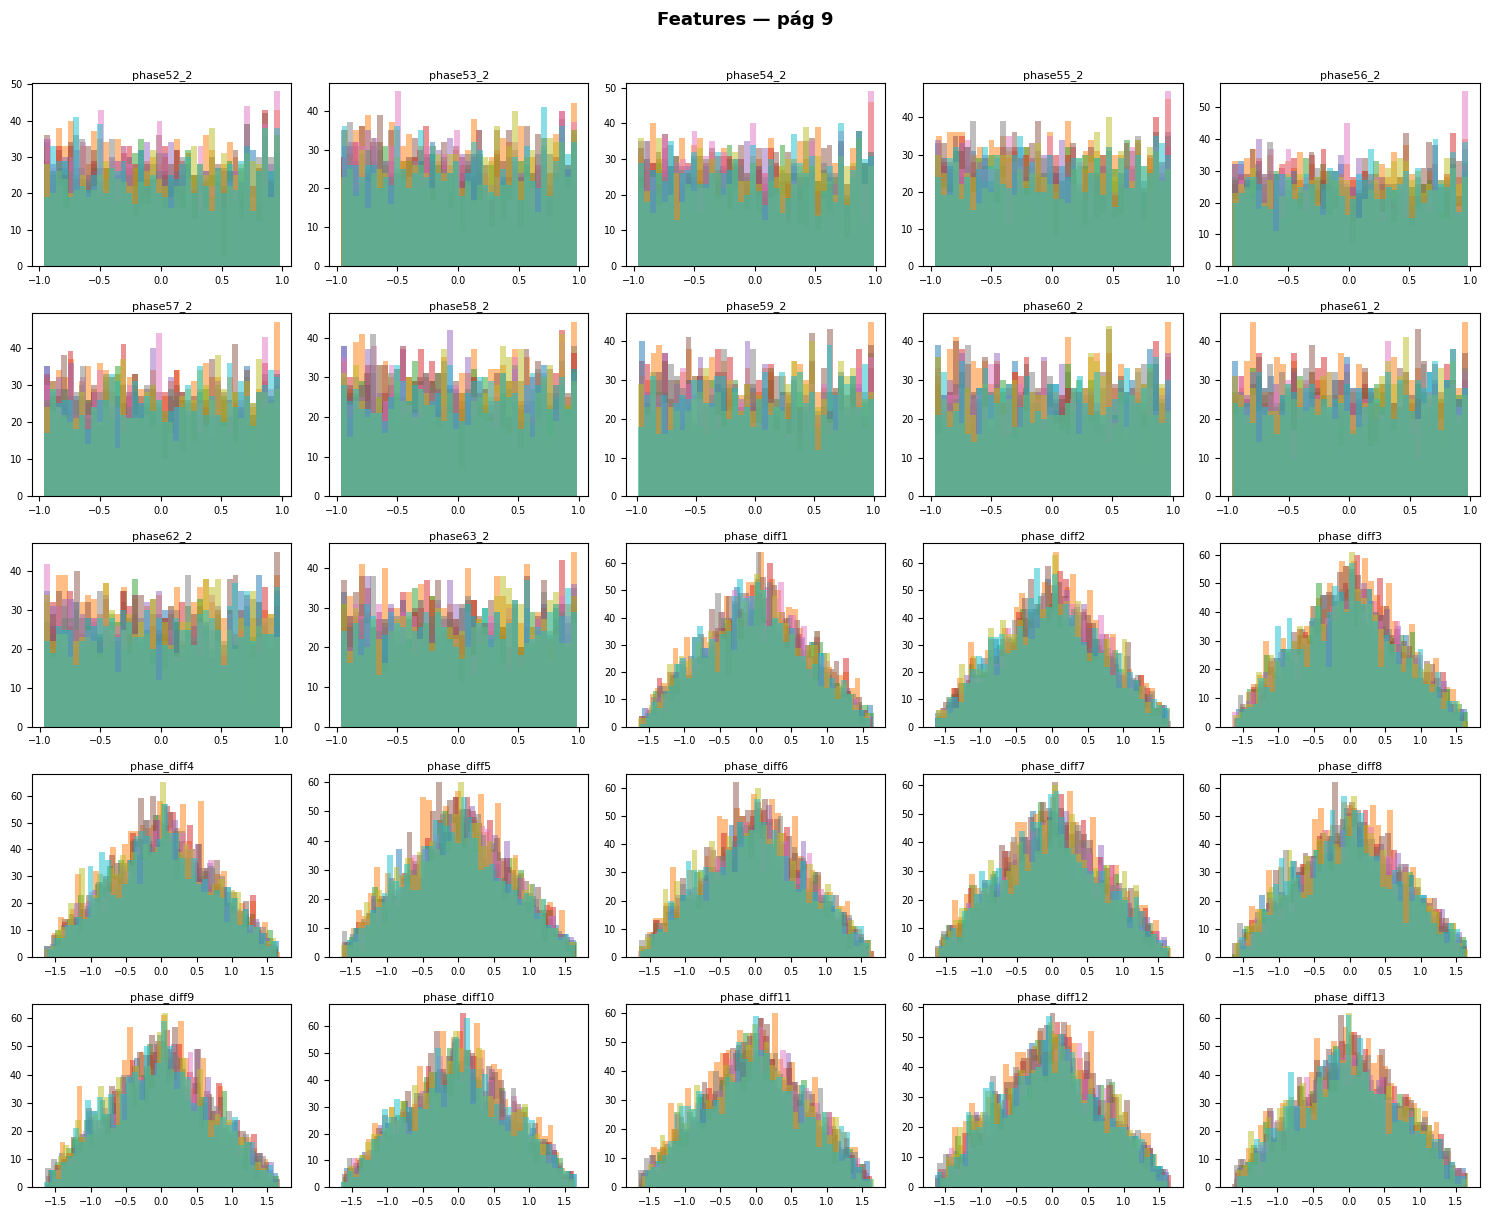

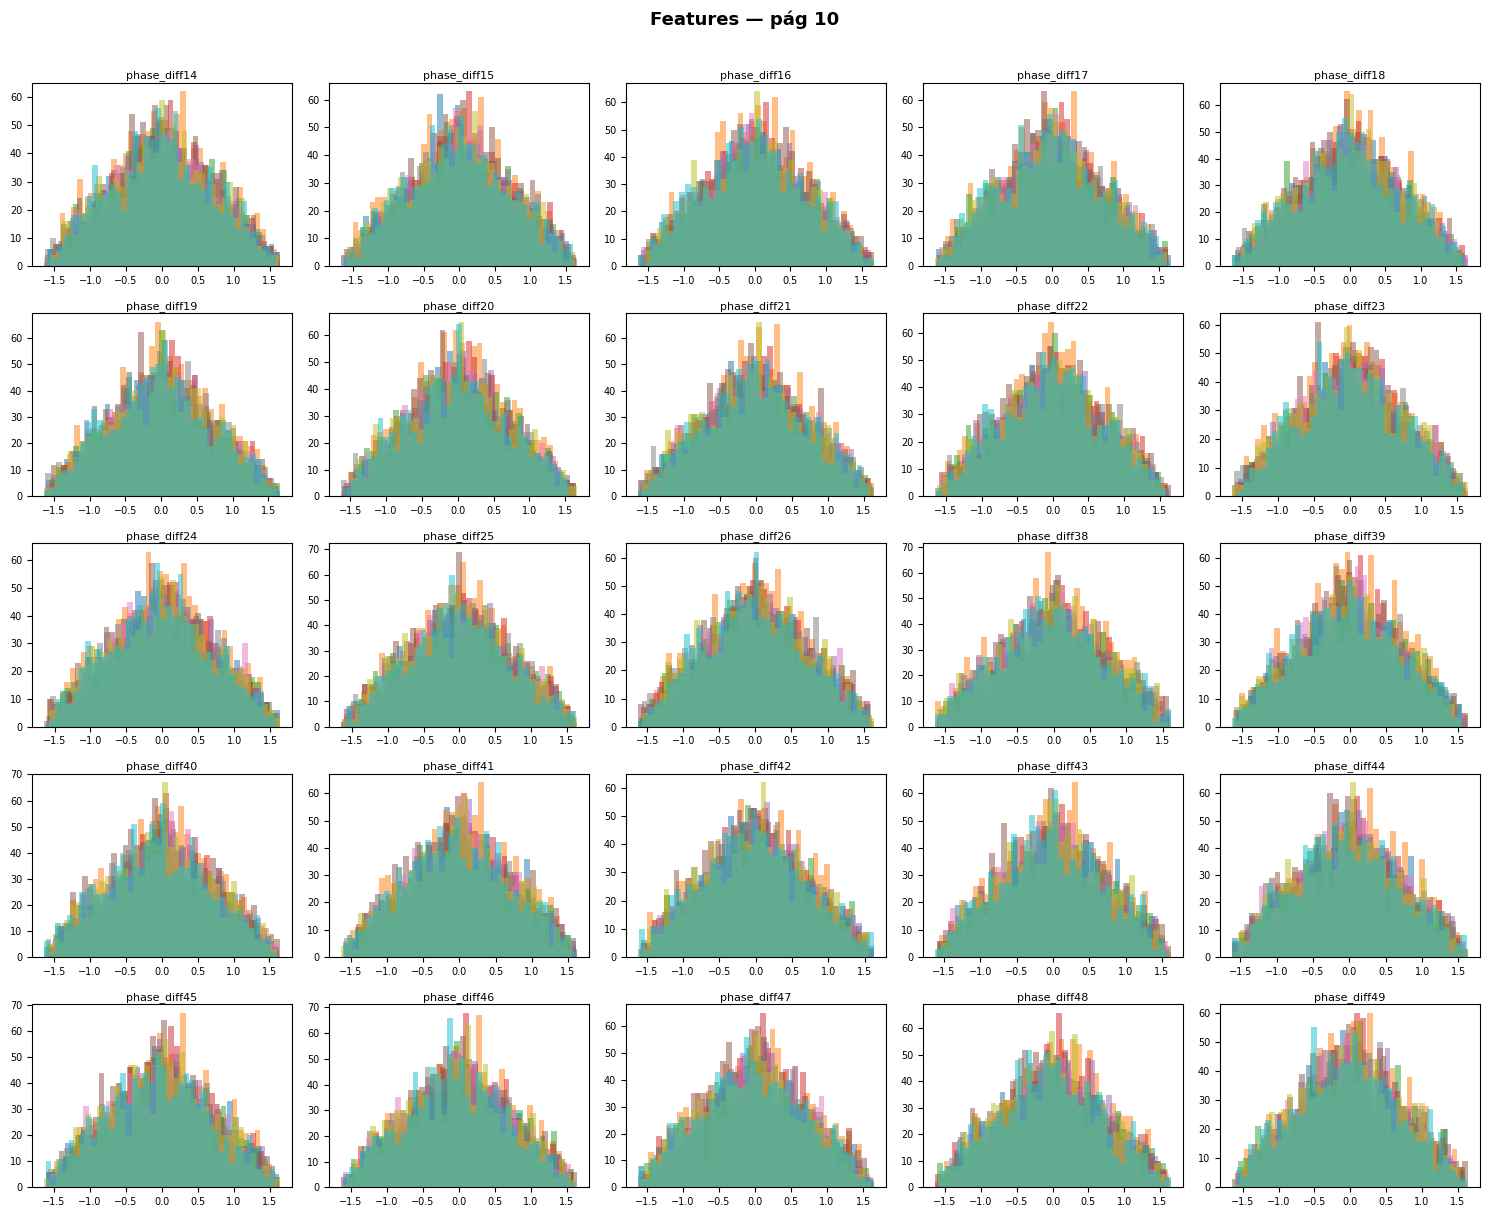

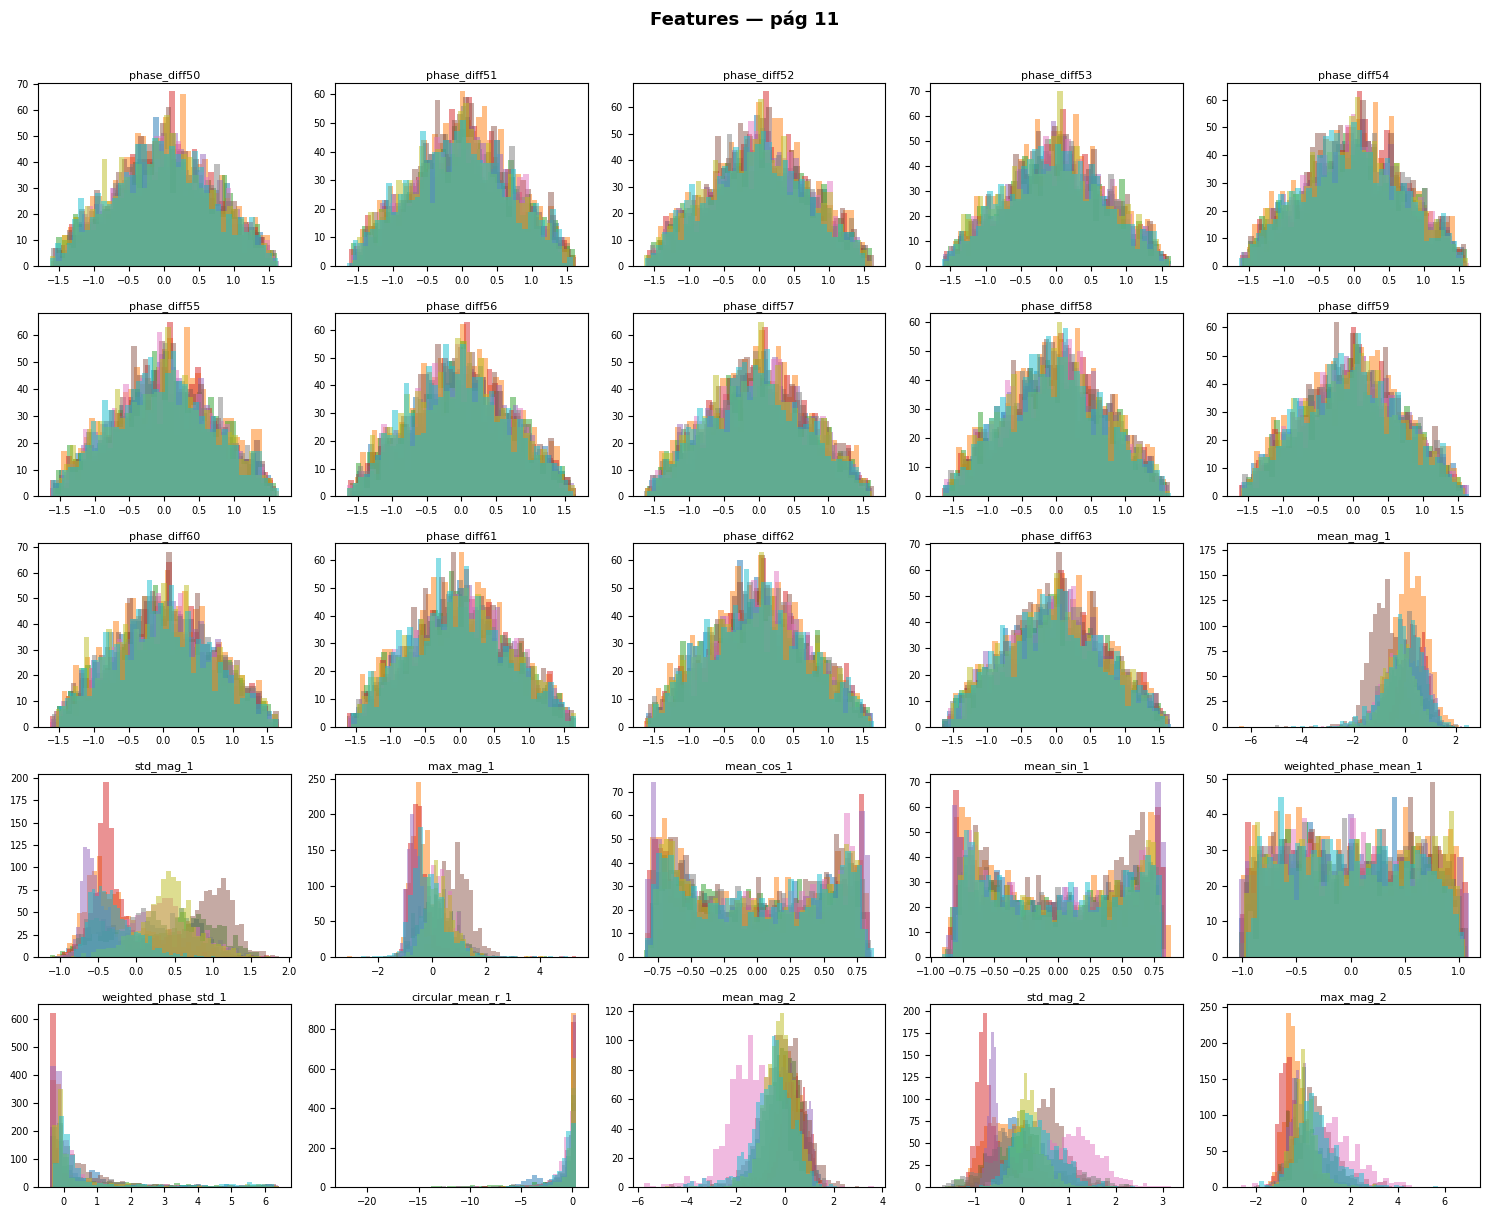

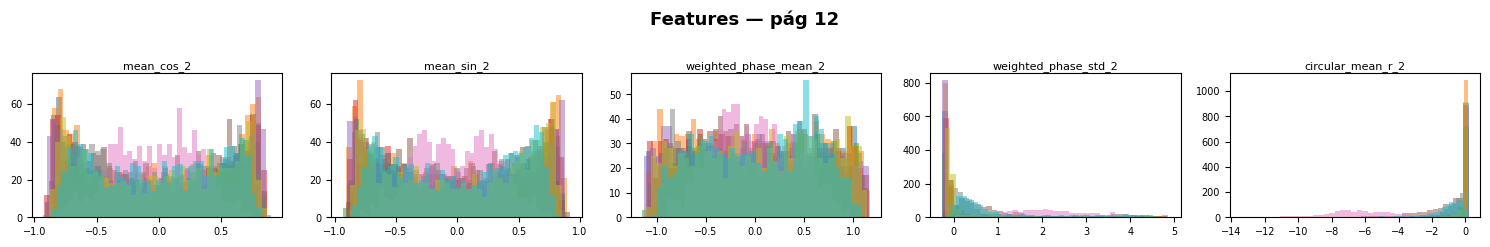

In [77]:
# Ver en pantalla
#plot_feature_histograms(X_train_filtered)

# Colorear por clase
#plot_feature_histograms(pd.concat([X_train_filtered, y_train_filtered], axis=1), by_class=True)

# Guardar PNGs
#plot_feature_histograms(X_train_filtered, output_dir="plots/")

# NORMALIZACIÓN DE LOS DATOS

MODELOS COMO KNN MISMO ESCALADO PARA HACER BIEN LOS CÁLCULOS DE LA DISTANCIA (NO DAR MÁS PESO A NINGUNA FEATURE)

Magnitudes (CSI) aprox 100: RobustScaler o StandardScaler
Por qué: El RobustScaler es ideal si detectas que hay valores extremos (outliers) que "estiran" mucho el histograma hacia la derecha, ya que utiliza la mediana y el rango intercuartílico en lugar de la media. Si después de limpiar los outliers las distribuciones parecen más estables, el StandardScaler (media 0, varianza 1) funcionará perfectamente para modelos como SVM o Redes Neuronales.

aoa: StandardScaler
Por qué: Al ser una distribución tan simétrica y similar a una Normal, el StandardScaler es el método más eficiente para centrarla y reducir su escala sin perder la relación angular que representa

rssi1 y rssi2: MinMaxScaler (rango 0 a 1) o StandardScaler
Por qué: El MinMaxScaler es muy útil aquí para transformar esos valores negativos a un rango positivo fácil de procesar para cualquier modelo. Sin embargo, si vas a usar un modelo de distancias como KNN, asegúrate de usar el mismo escalado que en las magnitudes para que el RSSI no pierda peso.

seq_ctrl: No escalar o eliminar.
Por qué: Según la guía, seq_ctrl es solo un número de secuencia. Si decides incluirlo, usa un escalado robusto, pero ten en cuenta que en problemas de localización física, el número de secuencia suele ser ruido que no ayuda a predecir la posición a menos que haya un sesgo temporal en la captura.


## CSI:

In [69]:
features = ['seq_ctrl', 'aoa', 'rssi1', 'rssi2']
col_magnitud = [col for col in X_train_filtered.columns if col not in features]

scaler = preprocessing.RobustScaler()

X_train_filtered[col_magnitud] = scaler.fit_transform(X_train_filtered[col_magnitud])
X_test[col_magnitud] = scaler.transform(X_test[col_magnitud])
X_test_nolabels[col_magnitud] = scaler.transform(X_test_nolabels[col_magnitud])

## aoa

In [70]:
scaler = preprocessing.StandardScaler()
X_train_filtered["aoa"] = scaler.fit_transform(X_train_filtered[["aoa"]])
X_test["aoa"] = scaler.transform(X_test[["aoa"]])
X_test_nolabels["aoa"] = scaler.transform(X_test_nolabels[["aoa"]])

array([<Axes: title={'center': 'aoa'}>], dtype=object)

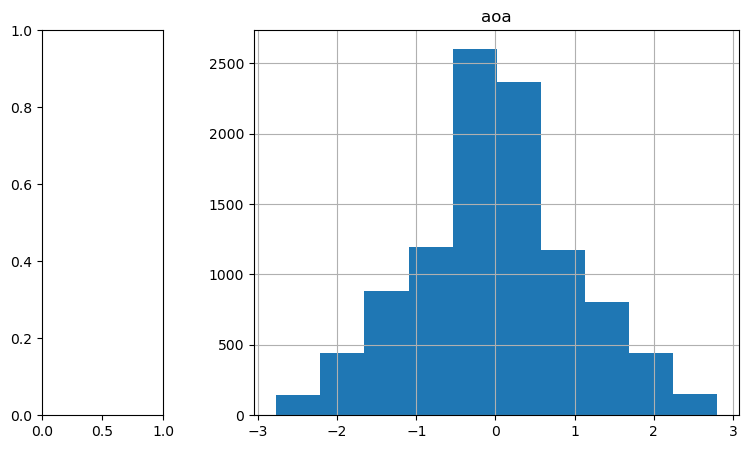

In [71]:
fig, axes= plt.subplots(1,2, gridspec_kw={'width_ratios': [1, 4]}, figsize=(9,5))
X_train_filtered.hist(column='aoa', ax=axes[1])

## rssi1 y rssi2:

In [72]:
scaler = preprocessing.StandardScaler()
X_train_filtered[["rssi1","rssi2"]] = scaler.fit_transform(X_train_filtered[["rssi1","rssi2"]])
X_test[["rssi1","rssi2"]] = scaler.transform(X_test[["rssi1","rssi2"]])
X_test_nolabels[["rssi1","rssi2"]] = scaler.transform(X_test_nolabels[["rssi1","rssi2"]])

array([<Axes: title={'center': 'rssi1'}>], dtype=object)

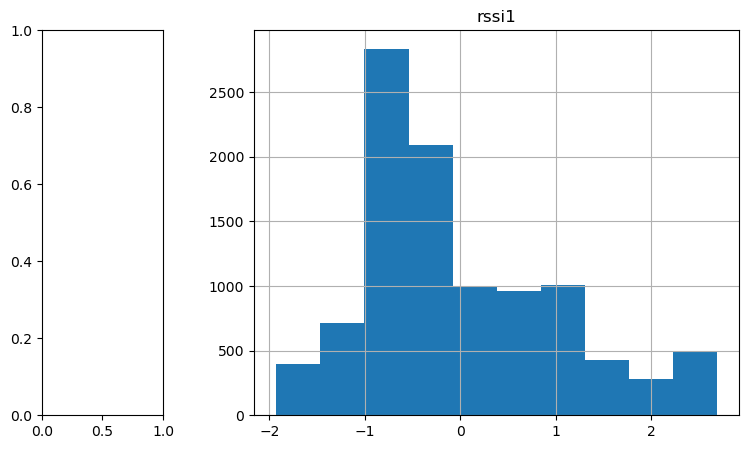

In [73]:
fig, axes= plt.subplots(1,2, gridspec_kw={'width_ratios': [1, 4]}, figsize=(9,5))
X_train_filtered.hist(column='rssi1', ax=axes[1])

array([<Axes: title={'center': 'rssi2'}>], dtype=object)

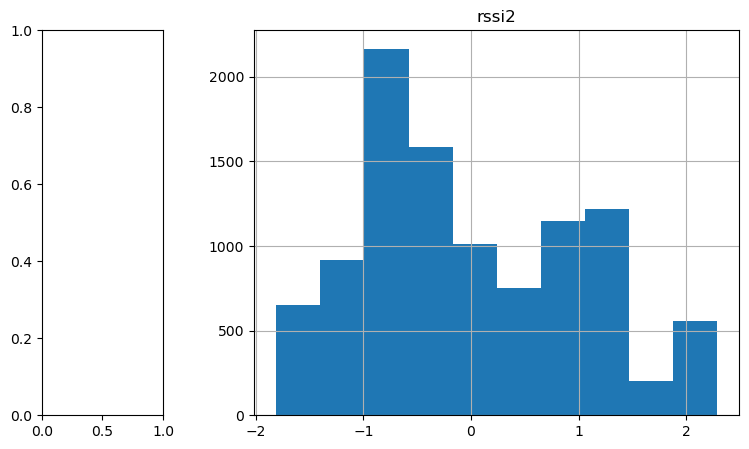

In [74]:
fig, axes= plt.subplots(1,2, gridspec_kw={'width_ratios': [1, 4]}, figsize=(9,5))
X_train_filtered.hist(column='rssi2', ax=axes[1])

In [75]:
X_train_filtered.shape, y_train_filtered.shape

((10210, 280), (10210,))

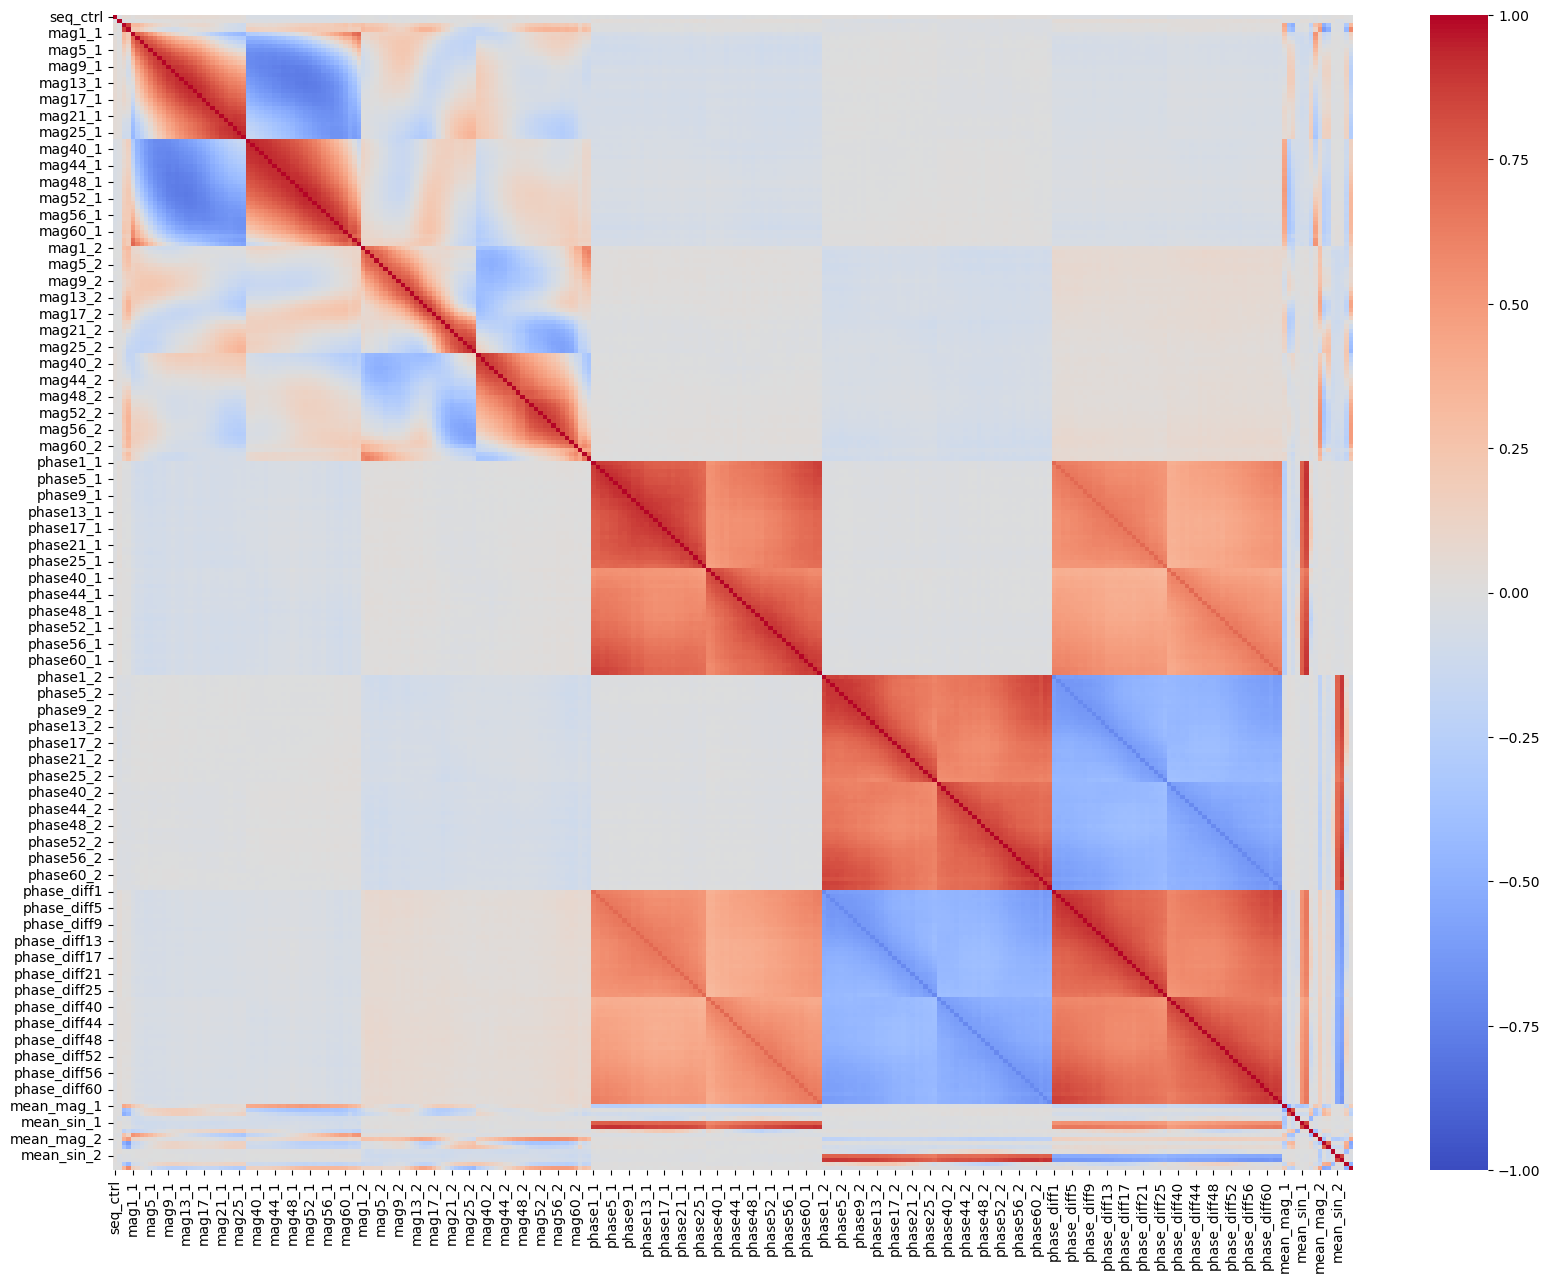

In [76]:
import seaborn

matriz_corr = X_train_filtered.corr()
plt.figure(figsize=(20, 15))
seaborn.heatmap(matriz_corr, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

c:\Users\dijor\anaconda3\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
c:\Users\dijor\anaconda3\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


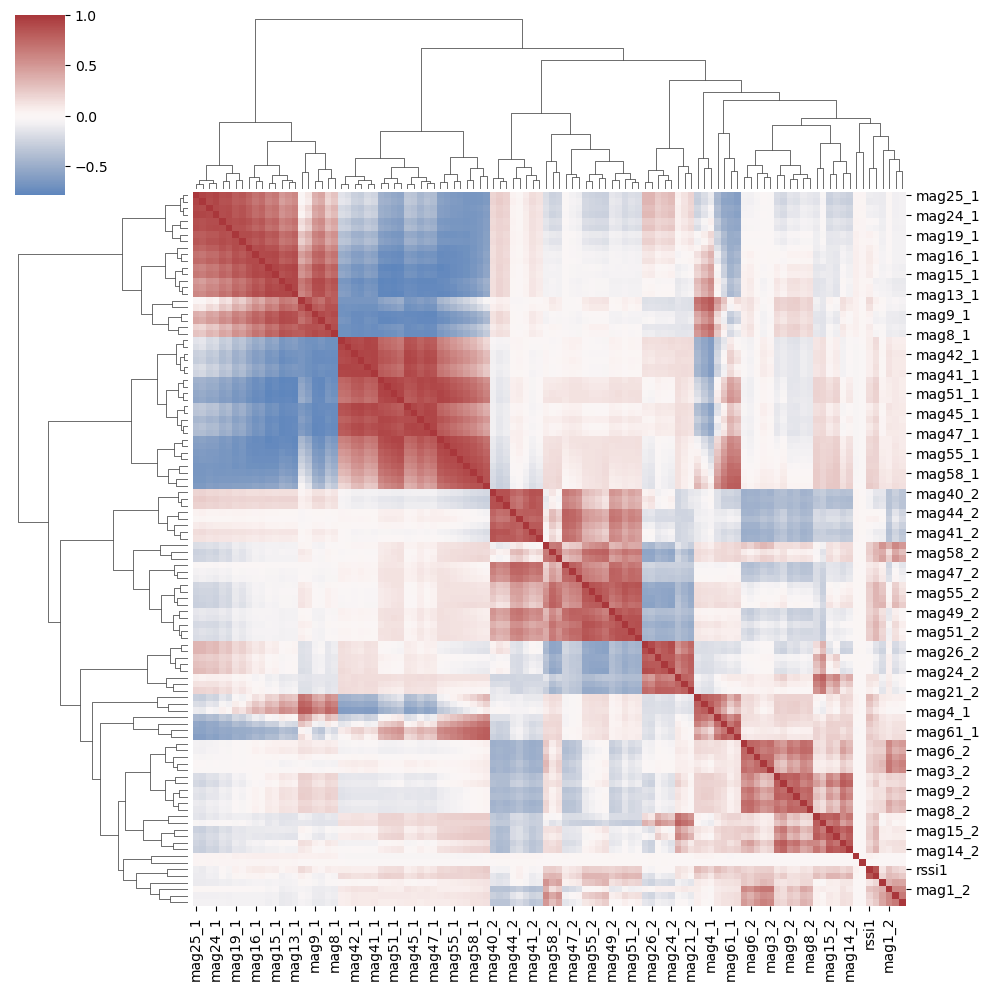

In [ ]:
seaborn.clustermap(X_train_filtered.corr(), annot=False, cmap='vlag', center=0)
plt.show()

In [78]:
corr_seq_ctrl = matriz_corr['seq_ctrl'].sort_values(ascending=False)
print(corr_seq_ctrl)

seq_ctrl    1.000
mag16_1     0.066
mag14_1     0.064
mag13_1     0.063
mag15_1     0.062
            ...  
mag54_1    -0.045
mag52_1    -0.045
mag55_1    -0.045
mag56_1    -0.047
mag57_1    -0.048
Name: seq_ctrl, Length: 280, dtype: float64


In [79]:
corr_aoa = matriz_corr['aoa'].sort_values(ascending=False)
print(corr_aoa)

aoa             1.000
phase_diff18    0.048
phase_diff12    0.047
phase_diff23    0.047
phase_diff19    0.046
                ...  
phase19_2      -0.041
phase15_2      -0.042
phase13_2      -0.042
phase12_2      -0.045
phase18_2      -0.047
Name: aoa, Length: 280, dtype: float64


In [80]:
corr_rssi1 = matriz_corr['rssi1'].sort_values(ascending=False)
print(corr_rssi1)

rssi1                   1.000
rssi2                   0.852
mean_mag_1              0.422
mean_mag_2              0.386
circular_mean_r_2       0.335
                        ...  
weighted_phase_std_2   -0.304
max_mag_2              -0.367
std_mag_1              -0.419
std_mag_2              -0.493
max_mag_1              -0.493
Name: rssi1, Length: 280, dtype: float64


In [81]:
corr_rssi2 = matriz_corr['rssi2'].sort_values(ascending=False)
print(corr_rssi2)

rssi2                   1.000
rssi1                   0.852
circular_mean_r_2       0.574
mean_mag_2              0.499
mean_mag_1              0.367
                        ...  
std_mag_1              -0.362
max_mag_1              -0.422
weighted_phase_std_2   -0.443
max_mag_2              -0.507
std_mag_2              -0.611
Name: rssi2, Length: 280, dtype: float64



seq_ctrl poco correlacionada con las otras features. (la quitamos?)
aoa poco correlacionada con las otras features.
rssi1 y rssi2 muy correlacionadas y tienen correlación (negativa y positiva) con las diferentes magnitudes.

In [82]:
print(X_train_filtered.shape, y_train_filtered.shape)

X_train_filtered.drop(columns=['seq_ctrl'], inplace=True)
X_test.drop(columns=['seq_ctrl'], inplace=True)
X_test_nolabels.drop(columns=['seq_ctrl'], inplace=True)


(10210, 280) (10210,)


In [83]:
X_train_filtered.to_csv('../data/processed/train_lof_features2_scaling.csv', index=False)
X_test.to_csv('../data/processed/test_lof_features2_scaling.csv', index=False)

y_train_filtered.to_csv('../data/processed/y_train_lof_features2_scaling.csv', index=False)
y_test.to_csv('../data/processed/y_test_lof_features2_scaling.csv', index=False)

X_test_nolabels.to_csv('../data/processed/test_nolabels_lof_features2_scaling.csv', index=False)
